In [2]:
# libraries
from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from lightgbm import plot_importance
from sklearn.datasets import make_classification
from sklearn.svm import SVC


# EDA

In [2]:
# load dataset
wine = load_wine()

# set the columns
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['cultivar'] = wine.target
df.shape


(178, 14)

In [4]:
df.head(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  culti

In [6]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Text(0.5, 1.0, 'Cultivar Distribution')

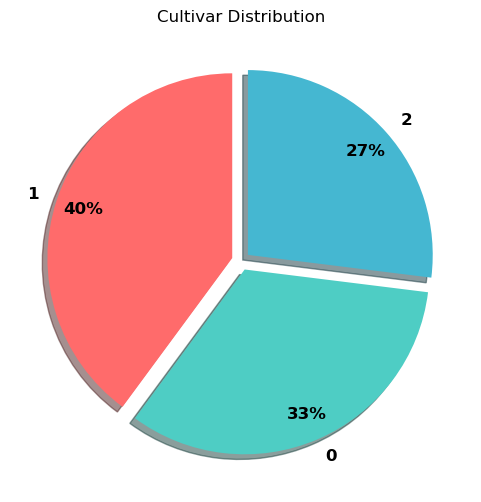

In [7]:
# data visualization
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

# colors
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# create pie chart 
pie_data = df['cultivar'].value_counts()


wedges, texts, autotexts = ax.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.0f%%',
    radius=1,
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05, 0.05),
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    pctdistance=0.85,
    labeldistance=1.1
)
ax.set_title('Cultivar Distribution')


In [ ]:
sns.pairplot(df, diag_kind = 'hist',hue='cultivar',
             plot_kws = {'alpha': 0.6, 's': 80, 'edgecolor': 'k'},
             size = 4)

In [9]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
173    False
174    False
175    False
176    False
177    False
Length: 178, dtype: bool

# Regression Methods

In [62]:
# copy of data for regression
reg_df = copy.deepcopy(df)

In [63]:
# fix data for regression

# set alcohol column as the target
alcohol_content = reg_df.pop('alcohol')

X_train, X_test, y_train, y_test = train_test_split(reg_df, alcohol_content, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(142, 13)
(36, 13)


In [12]:
reg_df.head()

,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [64]:
# normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
# linear regression 
lr = LinearRegression()
model = lr
model.fit(X_train_scaled, y_train)

LinearRegression()

In [66]:
test_predict = model.predict(X_test_scaled)
train_predict = model.predict(X_train_scaled)

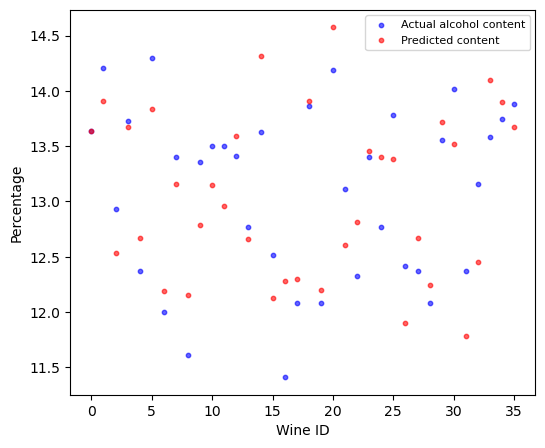

In [16]:
# comparing actual and predicted values
plt.figure(figsize=(6,5))
x = np.arange(0,len(y_test),1)
plt.scatter(x,y_test,c='b',s=10,alpha=0.6)
plt.scatter(x,test_predict,c='r',s=10,alpha=0.6)
plt.legend(['Actual alcohol content','Predicted content'],fontsize=8)
plt.ylabel('Percentage',fontsize=10)
plt.xlabel('Wine ID',fontsize=10)
plt.show()

In [67]:
# evaluation function
def evaluate_regression(y_true, y_pred, model_name):
    
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{model_name} Performance:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R² Score: {r2:.4f}")
    return {'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


In [68]:
# evaluate the results
results = {}
results['Linear Regression on Test'] = evaluate_regression(y_test, test_predict, "Linear Regression on Test")
on_train = evaluate_regression(y_train, train_predict, "Linear Regression on Train")


Linear Regression on Test Performance:
MSE: 0.1726
MAE: 0.3574
MAPE: 2.76%
R² Score: 0.7109

Linear Regression on Train Performance:
MSE: 0.2747
MAE: 0.4224
MAPE: 3.27%
R² Score: 0.5887


In [69]:
# checking for the weights
weights_linear = model.coef_

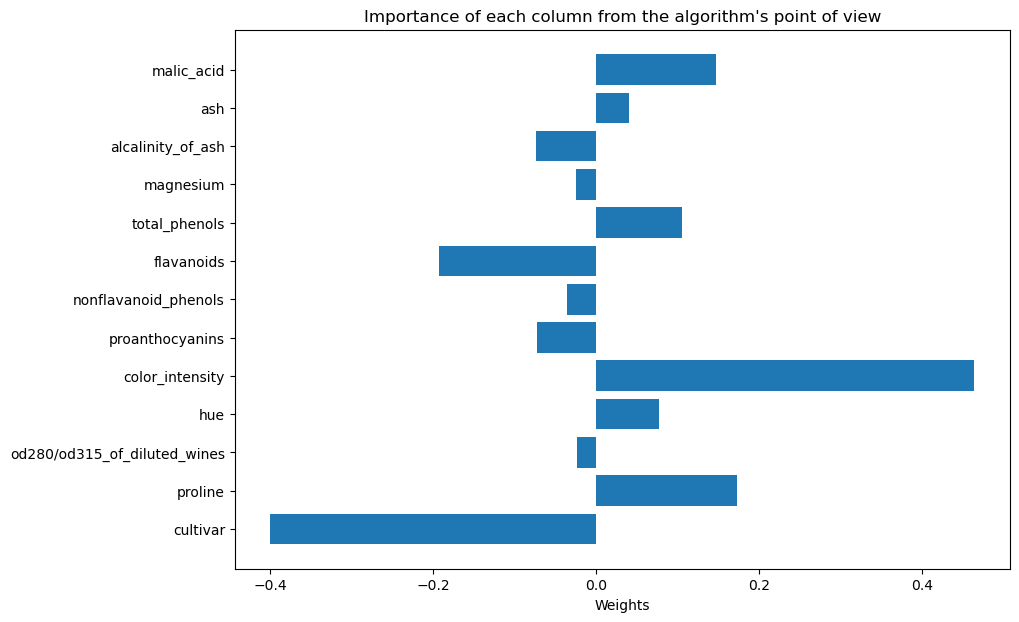

In [21]:
# visualization of the weights
fig, ax = plt.subplots(figsize=(10,7))
y_pos = np.arange(0,len(weights_linear),1)
labels = list(reg_df.columns)

hbars = ax.barh(y_pos, weights_linear, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()  
ax.set_xlabel('Weights')
ax.set_title("Importance of each column from the algorithm's point of view")
plt.show()

As we can see the model pays more attention to color intensity and cultivar, to explain this we should consider the factors that effect the alcohol level of wine, adding more sugar plays important role, so rape grapes usually produce higher alcohol levels, also they have higher color intensity, in this way we can explain why the model pays more attention to this column. Also the cultivar column specifies different cultivars that the wine is made of, we know that some cultivars can produce higher alcohol-level wines, so it is reasonable that the model pays attention to it.

<img src="./pic1.png" alt="pic1" width="400">

<img src="./pic2.png" alt="pic2" width="400">

<img src="./pic3.png" alt="pic3" width="400">

<img src="./pic4.png" alt="pic4" width="400">

In [70]:
# kernel regression
kr = KernelRidge(kernel='polynomial', alpha=1.0)
model = kr
model.fit(X_train_scaled, y_train)

KernelRidge(alpha=1.0, kernel='polynomial')

In [71]:
test_predict = model.predict(X_test_scaled)
train_predict = model.predict(X_train_scaled)

In [72]:

results['Kernel Regression on Test'] = evaluate_regression(y_test, test_predict, "Kernel Regression on Test")
on_train = evaluate_regression(y_train, train_predict, "Kernel Regression on Train")


Kernel Regression on Test Performance:
MSE: 0.3475
MAE: 0.4566
MAPE: 3.49%
R² Score: 0.4180

Kernel Regression on Train Performance:
MSE: 0.1501
MAE: 0.2897
MAPE: 2.21%
R² Score: 0.7753


In [73]:
# ridge regression
ridge = Ridge()
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
ridge = ridge_cv.best_estimator_
model = ridge

In [74]:

test_predict = model.predict(X_test_scaled)
train_predict = model.predict(X_train_scaled)


In [75]:

results['Ridge Regression on Test'] = evaluate_regression(y_test, test_predict, "Ridge Regression on Test")
on_train = evaluate_regression(y_train, train_predict, "Ridge Regression on Train")


Ridge Regression on Test Performance:
MSE: 0.1679
MAE: 0.3527
MAPE: 2.73%
R² Score: 0.7188

Ridge Regression on Train Performance:
MSE: 0.2798
MAE: 0.4227
MAPE: 3.27%
R² Score: 0.5810


In [76]:
# lasso
lasso = Lasso(max_iter=10000)
param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}
lasso_cv = GridSearchCV(lasso, param_grid, cv=5, scoring='r2')
lasso_cv.fit(X_train_scaled, y_train)
lasso = lasso_cv.best_estimator_
model = lasso

In [77]:
test_predict = model.predict(X_test_scaled)
train_predict = model.predict(X_train_scaled)

In [78]:

results['Lasso Regression on Test'] = evaluate_regression(y_test, test_predict, "Lasso Regression on Test")
on_train = evaluate_regression(y_train, train_predict, "Lasso Regression on Train")


Lasso Regression on Test Performance:
MSE: 0.1596
MAE: 0.3471
MAPE: 2.68%
R² Score: 0.7326

Lasso Regression on Train Performance:
MSE: 0.2797
MAE: 0.4204
MAPE: 3.25%
R² Score: 0.5811


In [79]:
# svr
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
model = svr
model.fit(X_train_scaled, y_train)

SVR()

In [80]:

test_predict = model.predict(X_test_scaled)
train_predict = model.predict(X_train_scaled)

In [81]:

results['SVM on Test'] = evaluate_regression(y_test, test_predict, "SVM on Test")
on_train = evaluate_regression(y_train, train_predict, "SVM on Train")


SVM on Test Performance:
MSE: 0.1541
MAE: 0.3342
MAPE: 2.56%
R² Score: 0.7418

SVM on Train Performance:
MSE: 0.1314
MAE: 0.2616
MAPE: 2.01%
R² Score: 0.8033


In [60]:
# decision tree
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
model = dt 
model.fit(X_train_scaled, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [61]:

test_predict = model.predict(X_test_scaled)
train_predict = model.predict(X_train_scaled)

In [62]:

results['Decision Tree on Test'] = evaluate_regression(y_test, test_predict, "Decision Tree on Test")
on_train = evaluate_regression(y_train, train_predict, "Decesion Tree Train")


Decision Tree on Test Performance:
MSE: 0.2117
MAE: 0.3886
MAPE: 2.97%
R² Score: 0.6454

Decesion Tree Train Performance:
MSE: 0.1158
MAE: 0.2504
MAPE: 1.93%
R² Score: 0.8266


In [63]:
# elasticnet
en = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
model = en
model.fit(X_train_scaled, y_train)

ElasticNet(alpha=0.1, max_iter=10000)

In [64]:

test_predict = model.predict(X_test_scaled)
train_predict = model.predict(X_train_scaled)

In [65]:

results['ElasticNet on Test'] = evaluate_regression(y_test, test_predict, "ElasticNet on Test")
on_train = evaluate_regression(y_train, train_predict, "ElasticNet on Train")


ElasticNet on Test Performance:
MSE: 0.1739
MAE: 0.3617
MAPE: 2.80%
R² Score: 0.7087

ElasticNet on Train Performance:
MSE: 0.3065
MAE: 0.4415
MAPE: 3.42%
R² Score: 0.5410


## The Kernel Trick

The kernel trick is a mathematical technique that allows algorithms to operate in a high-dimensional feature space without explicitly computing the coordinates in that space. It computes the similarity between points using a kernel function that implicitly maps data to higher dimensions.

### How It Improves Regression

- **Captures non-linear relationships**: Linear models can't capture patterns like curves, waves, or interactions

- **Computational efficiency**: Avoids expensive high-dimensional computations

- **Flexibility**: Different kernels (RBF, polynomial, sigmoid) capture different patterns

- **No explicit mapping needed**: The kernel function directly computes dot products in high-dimensional space


MODEL COMPARISON SUMMARY
                              MSE     MAE    MAPE      R2
SVM on Test                0.1541  0.3342  2.5601  0.7418
Lasso Regression on Test   0.1596  0.3471  2.6813  0.7326
Ridge Regression on Test   0.1679  0.3527  2.7313  0.7188
Linear Regression on Test  0.1726  0.3574  2.7622  0.7109
ElasticNet on Test         0.1739  0.3617  2.8008  0.7087
Decision Tree on Test      0.2117  0.3886  2.9729  0.6454
Kernel Regression on Test  0.3475  0.4566  3.4863  0.4180


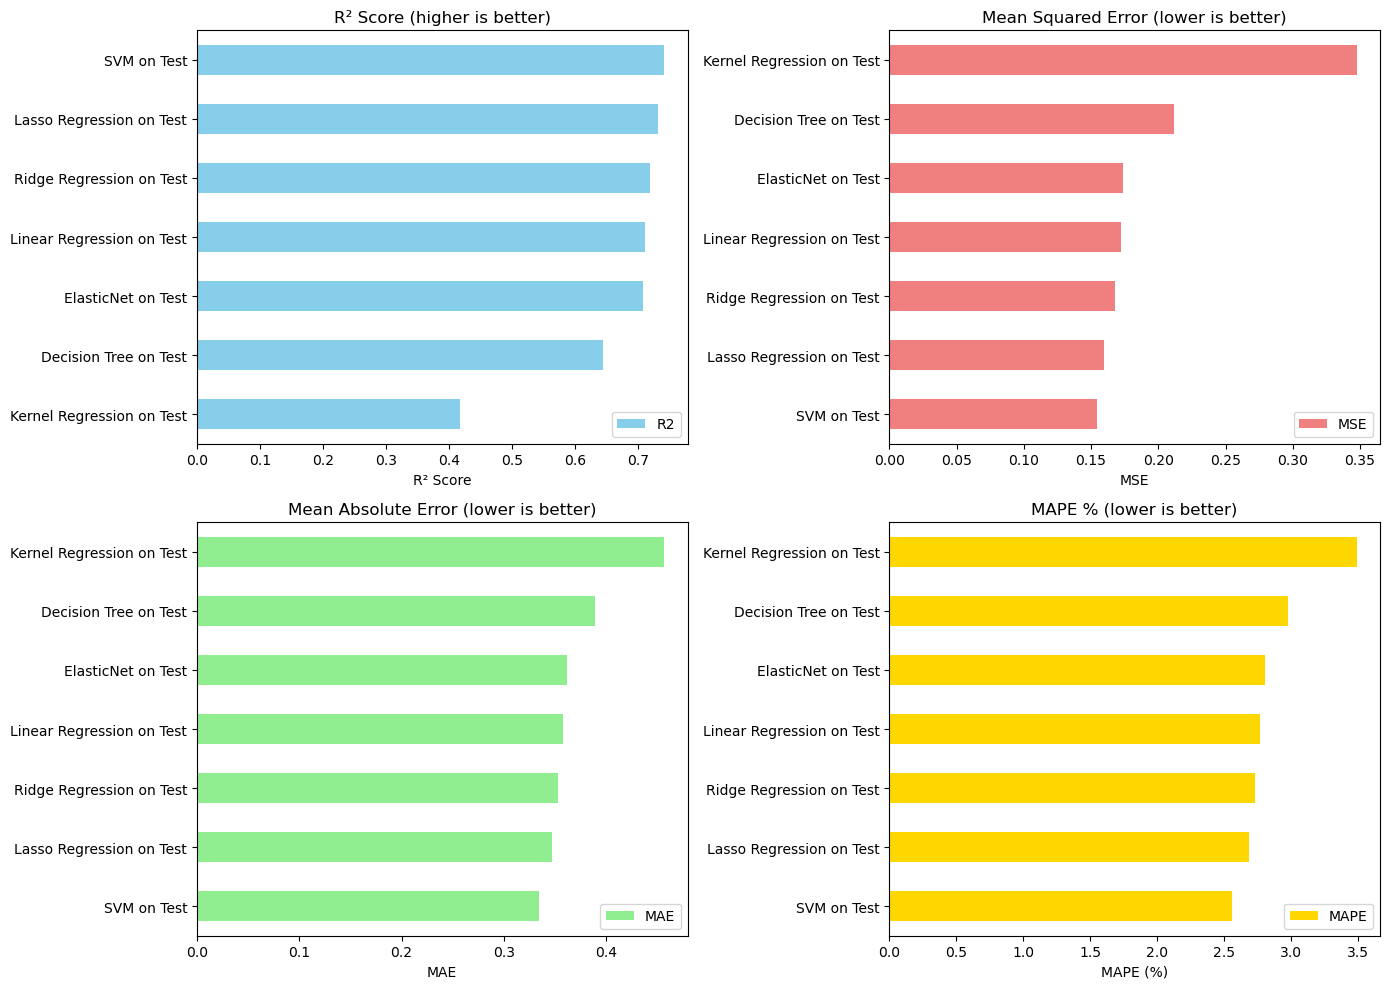

In [66]:
# create comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.sort_values('R2', ascending=False))

# visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# R² Score comparison
results_df.sort_values('R2', ascending=True).plot(kind='barh', y='R2', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('R² Score (higher is better)', fontsize=12)
axes[0,0].set_xlabel('R² Score')
axes[0,0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# MSE comparison
results_df.sort_values('MSE', ascending=True).plot(kind='barh', y='MSE', ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('Mean Squared Error (lower is better)', fontsize=12)
axes[0,1].set_xlabel('MSE')

# MAE comparison
results_df.sort_values('MAE', ascending=True).plot(kind='barh', y='MAE', ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Mean Absolute Error (lower is better)', fontsize=12)
axes[1,0].set_xlabel('MAE')

# MAPE comparison
results_df.sort_values('MAPE', ascending=True).plot(kind='barh', y='MAPE', ax=axes[1,1], color='gold')
axes[1,1].set_title('MAPE % (lower is better)', fontsize=12)
axes[1,1].set_xlabel('MAPE (%)')

plt.tight_layout()
plt.show()

# Best Regression Metric: MSE

1. **Penalizes Large Errors (Critical for Wine)**
- MSE squares errors before averaging → large errors heavily penalized
- A 1% ABV error (squared = 1) is 4x worse than a 0.5% error (squared = 0.25)
- In wine production, a 1% alcohol misprediction affects:
  - Regulatory compliance (label accuracy)
  - Quality control decisions
  - Wine blending formulas

2. **Differentiable & Optimization-Friendly**
- Smooth mathematical properties work with gradient descent
- Used as loss function in many regression algorithms (Ridge, Lasso, LinearRegression)
- Enables proper model training

3. **Consistent with Model Training**
- Most scikit-learn regression models minimize MSE internally
- Using MSE for evaluation aligns with how models were optimized


## Comparison with Other Metrics

| Metric | Pros | Cons | Verdict |
|--------|------|------|---------|
| **MSE** | ✓ Penalizes large errors<br>✓ Differentiable<br>✓ Aligns with model training | ✗ Units are squared (%² ABV) | **BEST** |
| **MAE** | ✓ Interpretable (% ABV)<br>✓ Robust to outliers | ✗ No large error penalty<br>✗ Not differentiable at 0 | 2nd best |
| **MAPE** | ✓ Scale-independent<br>✓ Intuitive as percentage | ✗ Undefined if actual=0<br>✗ Asymmetric penalty<br>✗ Unstable for small values | Poor |
| **R²** | ✓ Variance explained<br>✓ Good for comparison | ✗ Not in original units<br>✗ Can be misleading with low variance | Supplementary only |


---

# When to Prefer Each Regression Model

## 1. Linear Regression
**Prefer when:**
- Linear relationship exists between features and target
- Interpretability is crucial (easy to explain coefficients)
- Small to medium dataset (n_samples > n_features)
- Baseline model needed for comparison

**Avoid when:**
- Strong non-linear patterns exist
- Severe multicollinearity
- n_features >> n_samples (overfitting risk)

---

## 2. Kernel Regression / Kernel Ridge
**Prefer when:**
- Non-linear relationships present but unknown form
- Smooth continuous functions
- Small to medium dataset (< 10,000 samples)
- Complex patterns that linear models can't capture

**The Kernel Trick:** Mathematical technique that maps data to higher dimensions without explicit computation. Benefits:
- Captures non-linear relationships (curves, waves, interactions)
- Computational efficiency (avoids high-dimensional computations)
- Flexibility (RBF, polynomial, sigmoid kernels)
- No explicit mapping needed

**Avoid when:**
- Large datasets (O(n³) complexity)
- Linear relationships exist (wasteful)
- Interpretability needed

---

## 3. Ridge Regression (L2 Regularization)
**Prefer when:**
- Multicollinearity exists (correlated features)
- Many features (p > n or p close to n)
- Overfitting is a concern
- All features are potentially useful
- Stable coefficients needed

**Formula:** Loss = MSE + α × Σ(βᵢ²)

**Avoid when:**
- Feature selection needed (use LASSO)
- Interpretability is critical (coefficients are biased)
- Sparse solutions required

---

## 4. LASSO Regression (L1 Regularization)
**Prefer when:**
- Feature selection needed (automatically selects important features)
- Sparse solution desired (many coefficients become zero)
- High-dimensional data with irrelevant features
- Interpretability with fewer features

**Formula:** Loss = MSE + α × Σ|βᵢ|

**Avoid when:**
- Features are highly correlated (LASSO picks one arbitrarily)
- n < p (Ridge might be better)
- You need all features

---

## 5. Decision Tree Regression
**Prefer when:**
- Non-linear, non-smooth relationships (step functions)
- Complex interaction effects
- Interpretability via tree visualization
- Missing values present
- Different scales (no scaling needed)
- Outliers present (robust to outliers)

**Avoid when:**
- Smooth continuous functions (trees are stepwise)
- Small datasets (overfitting)
- Extrapolation needed (trees can't extrapolate)
- Linear relationships exist (wasteful)

---

## 6. SVR (Support Vector Regression)
**Prefer when:**
- Non-linear patterns with margin tolerance
- Clean data with few outliers
- Medium datasets (n < 10,000)
- High-dimensional feature space
- Kernel flexibility needed

**Kernel options:**
- **Linear:** K(x,y) = x·y
- **RBF:** K(x,y) = exp(-γ||x-y||²)
- **Polynomial:** K(x,y) = (γ·x·y + r)ᵈ
- **Sigmoid:** K(x,y) = tanh(γ·x·y + r)

**Avoid when:**
- Large datasets (O(n²) to O(n³) complexity)
- Many outliers
- Interpretability needed
- Probability estimates required

---

## 7. Elastic Net (L1 + L2)
**Prefer when:**
- Both feature selection AND regularization needed
- Correlated features (LASSO struggles, Elastic Net handles better)
- More features than samples (p >> n)
- Grouped feature selection desired

**Formula:** Loss = MSE + α × (ρ × Σ|βᵢ| + (1-ρ)/2 × Σβᵢ²)

Where ρ (l1_ratio) controls the balance:
- ρ = 1 → Pure LASSO
- ρ = 0 → Pure Ridge
- 0 < ρ < 1 → Elastic Net

**Avoid when:**
- Interpretability of pure LASSO needed
- Computational resources limited (more parameters to tune)
- Simple solution exists (use Ridge or LASSO alone)



# Binary Classification Methods

In [3]:
# copy of data for binary classification
biclass_df = copy.deepcopy(df)

In [4]:
# classify alcohol percentage in to 2 groups
biclass_df['alcohol plus 13'] = (biclass_df['alcohol'] >= 13).astype(int)
biclass_df['alcohol plus 13'].value_counts()

alcohol plus 13
1    92
0    86
Name: count, dtype: int64

In [105]:
biclass_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar,alcohol plus 13
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,1
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,1
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,1


In [5]:
# separate 2 target columns for classification
alcohol_class = biclass_df.pop('alcohol plus 13')
biclass_df = biclass_df.drop('alcohol', axis=1)

X_train, X_test, y_train, y_test = train_test_split(biclass_df, alcohol_class, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(142, 13)
(36, 13)


In [6]:
# normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# evaluate binary classification
def evaluate_classifier(y_test, y_pred, y_prob, model_name):
    
    # Basic metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # ROC-AUC
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax1)
    ax1.set_title(f'{model_name} - Confusion Matrix')
    
    # Plot ROC curve
    if y_prob is not None:
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        ax2.plot(fpr, tpr, color='darkorange', lw=2, 
                 label=f'ROC curve (AUC = {auc:.4f})')
        ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                 label='Random Classifier')
        ax2.set_xlim([0.0, 1.0])
        ax2.set_ylim([0.0, 1.05])
        ax2.set_xlabel('False Positive Rate (1 - Specificity)')
        ax2.set_ylabel('True Positive Rate (Sensitivity)')
        ax2.set_title(f'{model_name} - ROC Curve')
        ax2.legend(loc="lower right")
        ax2.grid(alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'ROC Curve Not Available\n(No probability estimates)', 
                 ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title(f'{model_name} - ROC Curve (N/A)')
    
    plt.tight_layout()
    plt.show()
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'AUC': auc
    }
    
    print(f"{model_name} Performance:")
    print(f"Accuracy:     {accuracy:.4f}")
    print(f"Precision:    {precision:.4f}")
    print(f"Recall:       {recall:.4f}")
    print(f"F1-Score:     {f1:.4f}")
    print(f"Sensitivity:  {sensitivity:.4f}")
    print(f"Specificity:  {specificity:.4f}")
    print(f"AUC:          {auc:.4f}" if auc else "AUC: N/A")
    
    print(f"\nConfusion Matrix:")
    print(f"            Predicted")
    print(f"            Neg   Pos")
    print(f"Actual Neg  {tn:3d}   {fp:3d}")
    print(f"       Pos  {fn:3d}   {tp:3d}")
    
    return results

In [8]:
# logistic regression 
logreg = LogisticRegression(max_iter=120)
model = logreg
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=120)

In [9]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

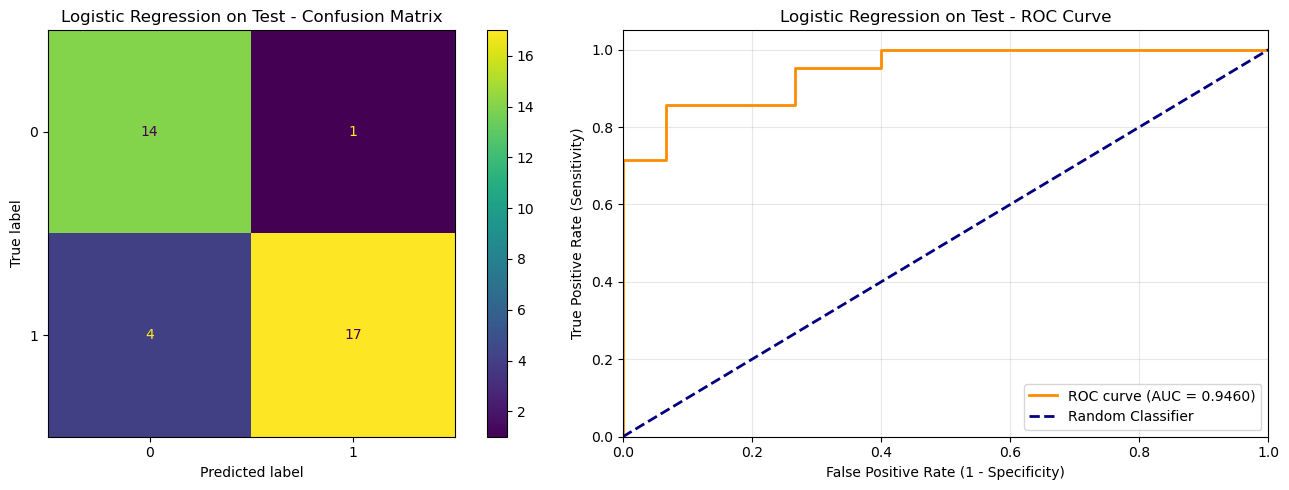

Logistic Regression on Test Performance:
Accuracy:     0.8611
Precision:    0.9444
Recall:       0.8095
F1-Score:     0.8718
Sensitivity:  0.8095
Specificity:  0.9333
AUC:          0.9460

Confusion Matrix:
            Predicted
            Neg   Pos
Actual Neg   14     1
       Pos    4    17


In [10]:
# evaluate results
results = {}
results['Logistic Regression on Test'] = evaluate_classifier(y_test, test_predict, test_prob, "Logistic Regression on Test")

In [11]:
# svm
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
model = svm_linear
model.fit(X_train_scaled, y_train)

SVC(kernel='linear', probability=True, random_state=42)

In [12]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

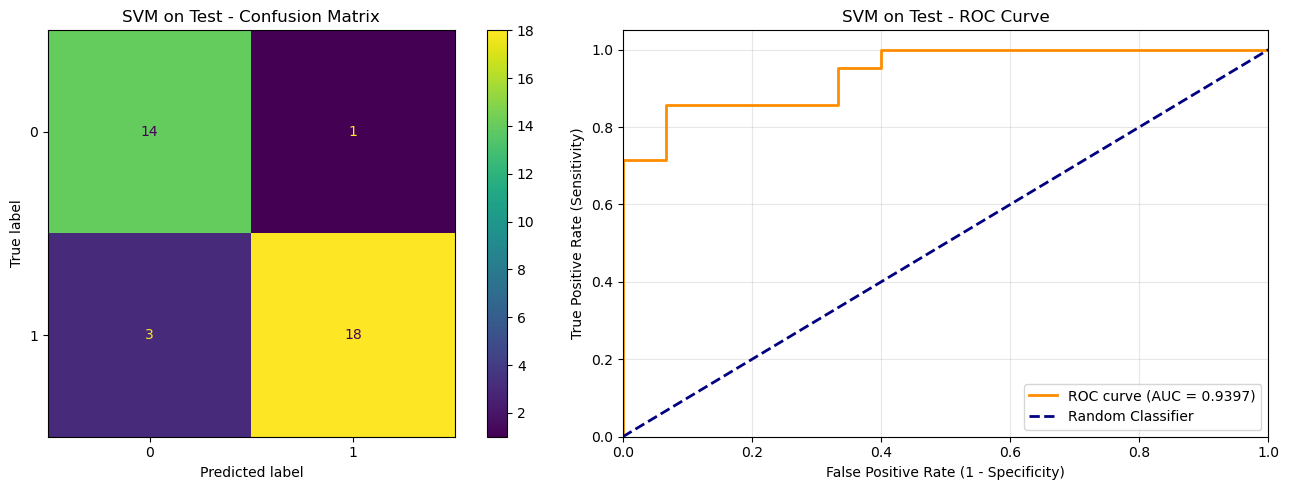

SVM on Test Performance:
Accuracy:     0.8889
Precision:    0.9474
Recall:       0.8571
F1-Score:     0.9000
Sensitivity:  0.8571
Specificity:  0.9333
AUC:          0.9397

Confusion Matrix:
            Predicted
            Neg   Pos
Actual Neg   14     1
       Pos    3    18


In [13]:

results['SVM on Test'] = evaluate_classifier(y_test, test_predict, test_prob, "SVM on Test")

In [115]:
# check the weights
weights_linear = model.coef_[0]

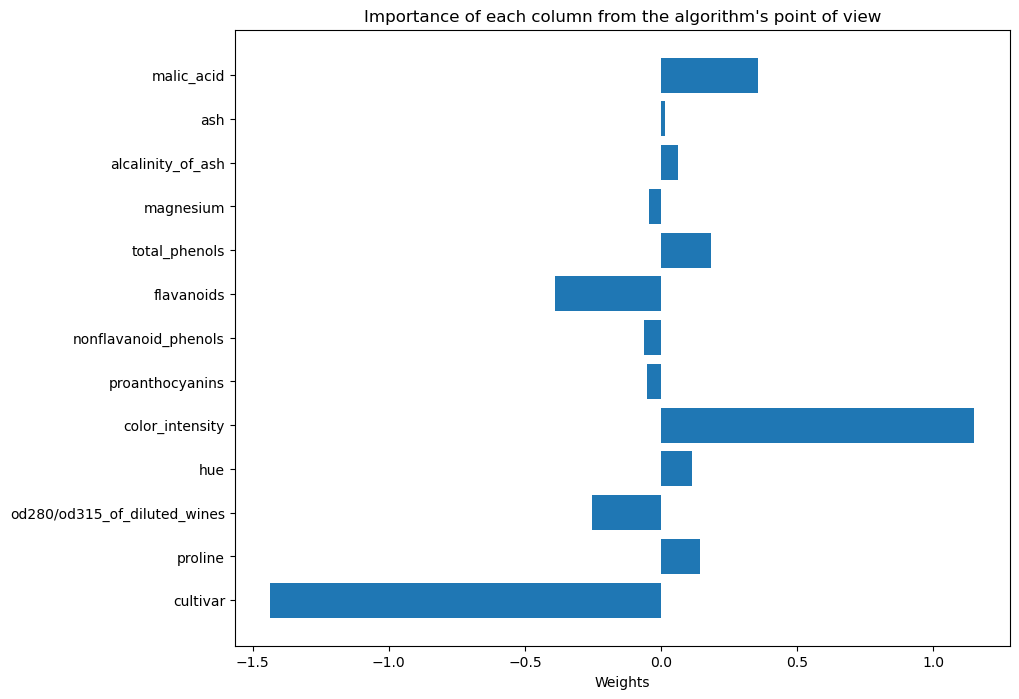

In [116]:
fig, ax = plt.subplots(figsize=(10,8))
y_pos = np.arange(0,len(weights_linear),1)
labels = list(biclass_df.columns)

hbars = ax.barh(y_pos, weights_linear, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()  
ax.set_xlabel('Weights')
ax.set_title("Importance of each column from the algorithm's point of view")

plt.show()

In [14]:
# kernel svm
svm_kernel = SVC(kernel='rbf', probability=True, random_state=42)
model = svm_kernel
model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [15]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

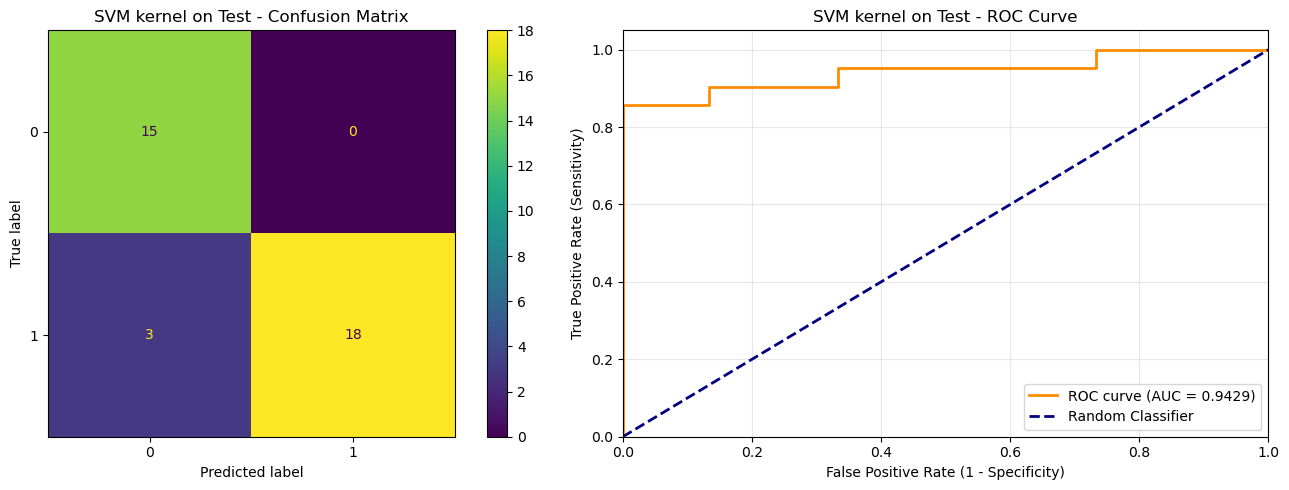

SVM kernel on Test Performance:
Accuracy:     0.9167
Precision:    1.0000
Recall:       0.8571
F1-Score:     0.9231
Sensitivity:  0.8571
Specificity:  1.0000
AUC:          0.9429

Confusion Matrix:
            Predicted
            Neg   Pos
Actual Neg   15     0
       Pos    3    18


In [16]:

results['SVM kernel on Test'] = evaluate_classifier(y_test, test_predict, test_prob, "SVM kernel on Test")

Best K value: 8 (F1-score: 0.8060)


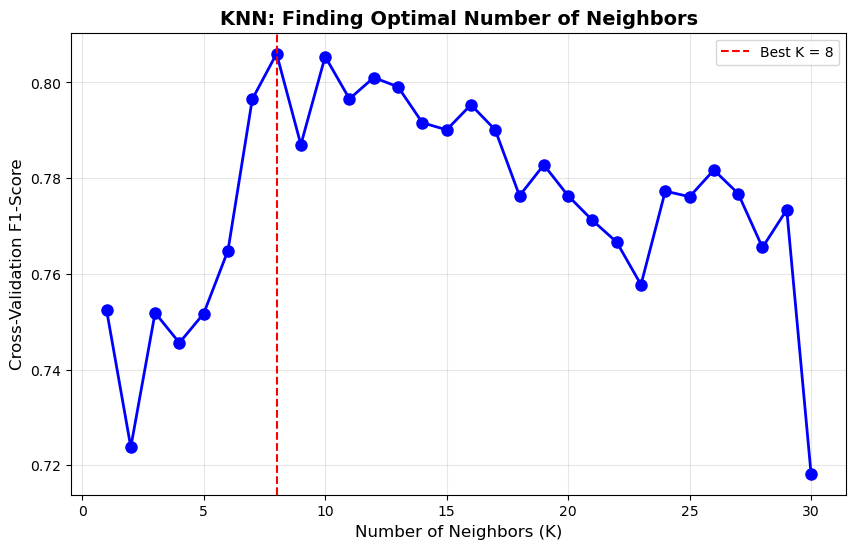

In [17]:
# tune k-values 
k_values = range(1, 31)
knn_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='f1')
    knn_scores.append(scores.mean())

best_k = k_values[np.argmax(knn_scores)]
print(f"Best K value: {best_k} (F1-score: {max(knn_scores):.4f})")

# plot K vs Performance
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_values, knn_scores, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
ax.set_xlabel('Number of Neighbors (K)', fontsize=12)
ax.set_ylabel('Cross-Validation F1-Score', fontsize=12)
ax.set_title('KNN: Finding Optimal Number of Neighbors', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [18]:
# knn (trained with k = 8)
knn = KNeighborsClassifier(n_neighbors=best_k,weights='distance')
model = knn
model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=8, weights='distance')

In [19]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

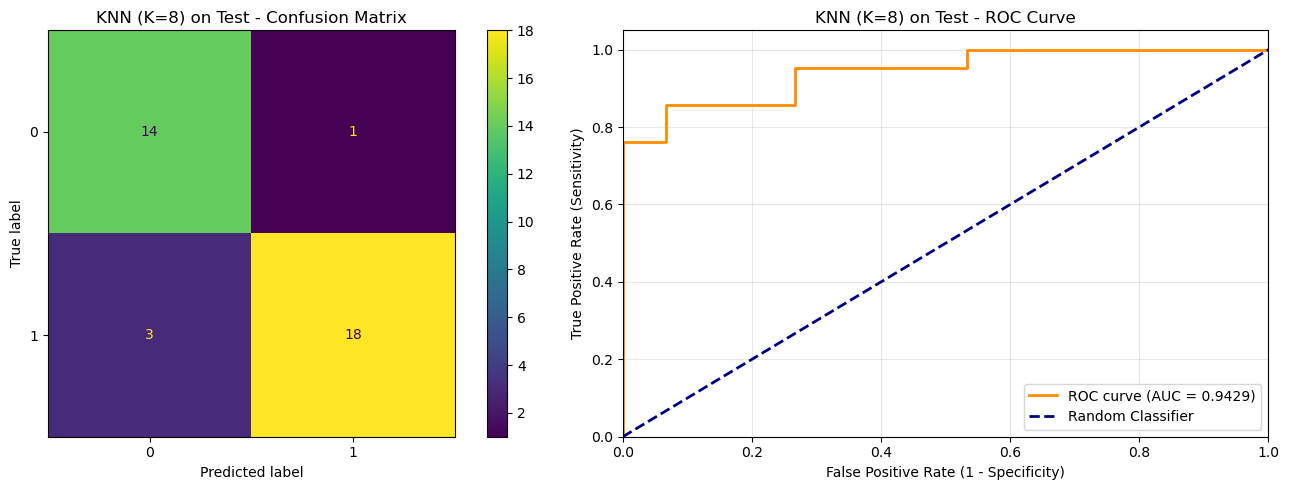

KNN (K=8) on Test Performance:
Accuracy:     0.8889
Precision:    0.9474
Recall:       0.8571
F1-Score:     0.9000
Sensitivity:  0.8571
Specificity:  0.9333
AUC:          0.9429

Confusion Matrix:
            Predicted
            Neg   Pos
Actual Neg   14     1
       Pos    3    18


In [20]:

results['KNN on Test'] = evaluate_classifier(y_test, test_predict, test_prob, f"KNN (K={best_k}) on Test")

Best max_depth: 2 (F1-score: 0.7980)


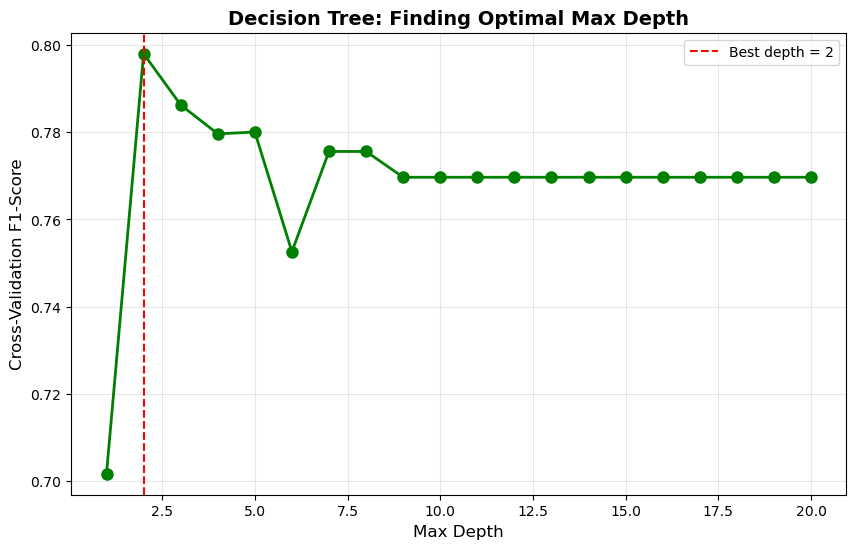

In [21]:
# tune tree depth
depth_values = range(1, 21)
dt_scores = []

for depth in depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt, X_train_scaled, y_train, cv=5, scoring='f1')
    dt_scores.append(scores.mean())

best_depth = depth_values[np.argmax(dt_scores)]
print(f"Best max_depth: {best_depth} (F1-score: {max(dt_scores):.4f})")

# plot Depth vs Performance
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depth_values, dt_scores, 'go-', linewidth=2, markersize=8)
ax.axvline(x=best_depth, color='red', linestyle='--', label=f'Best depth = {best_depth}')
ax.set_xlabel('Max Depth', fontsize=12)
ax.set_ylabel('Cross-Validation F1-Score', fontsize=12)
ax.set_title('Decision Tree: Finding Optimal Max Depth', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [22]:
# decision tree (trained with depth = 2)
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
model = dt_best
model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [23]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

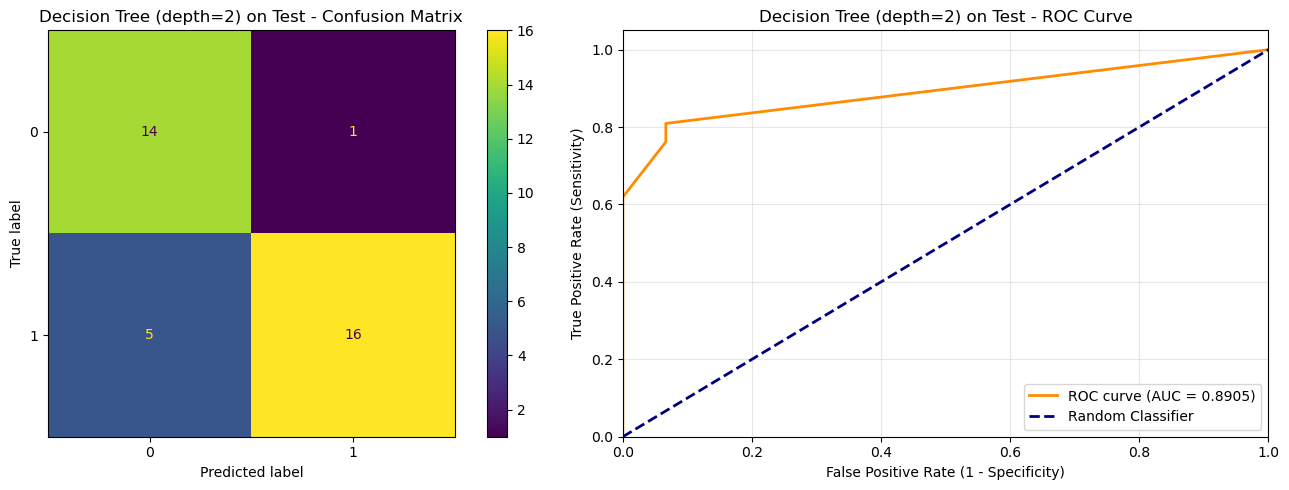

Decision Tree (depth=2) on Test Performance:
Accuracy:     0.8333
Precision:    0.9412
Recall:       0.7619
F1-Score:     0.8421
Sensitivity:  0.7619
Specificity:  0.9333
AUC:          0.8905

Confusion Matrix:
            Predicted
            Neg   Pos
Actual Neg   14     1
       Pos    5    16


In [24]:

results['Decision Tree on Test'] = evaluate_classifier(y_test, test_predict, test_prob, f"Decision Tree (depth={best_depth}) on Test")

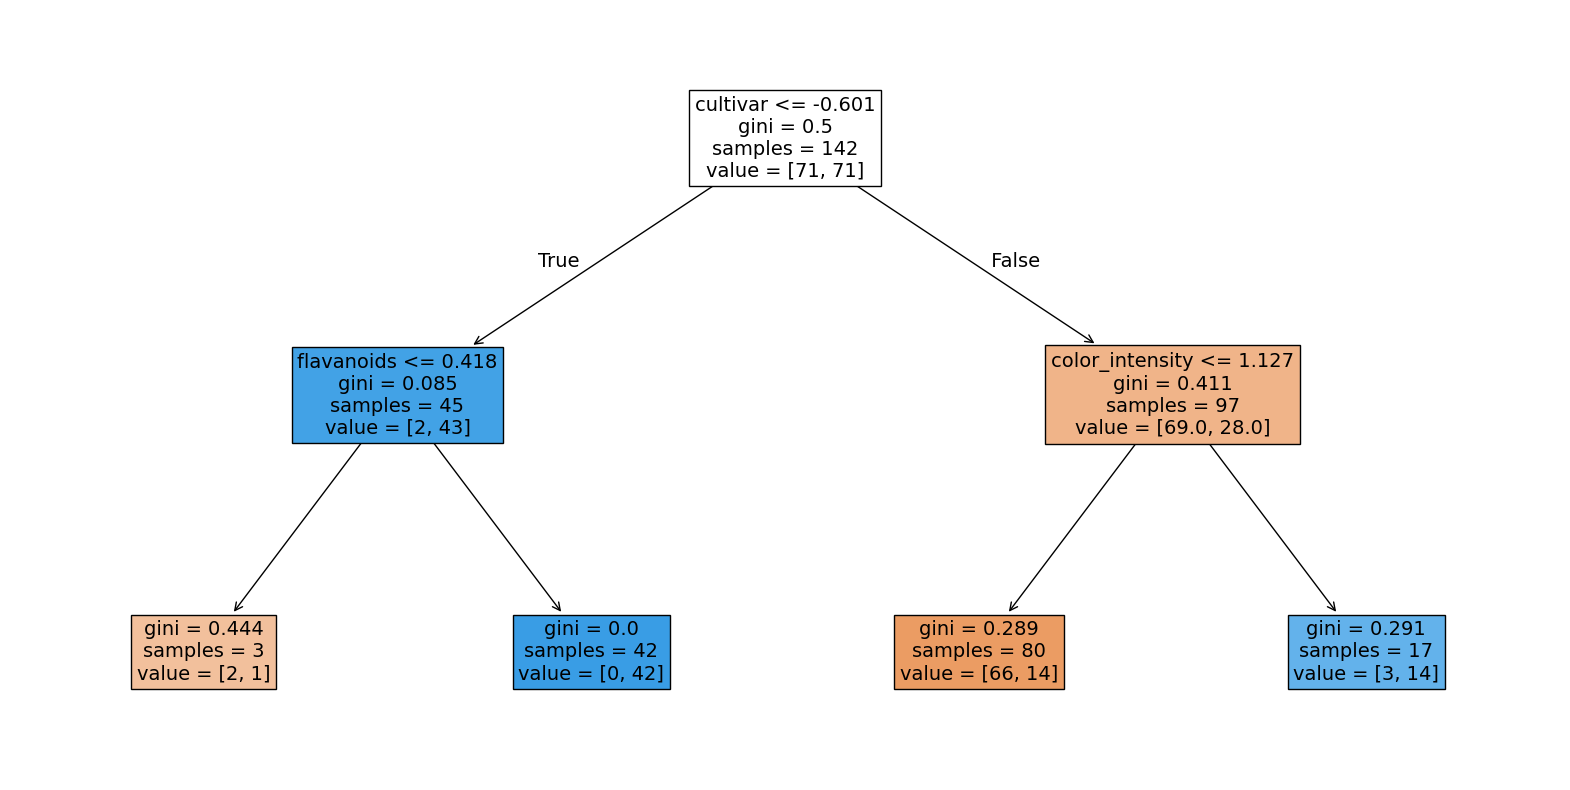

In [128]:
# tree visualisation
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (20,10))
tree.plot_tree(model,feature_names = biclass_df.columns, filled = True, fontsize=14);

In [25]:
# random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
model = rf
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [26]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

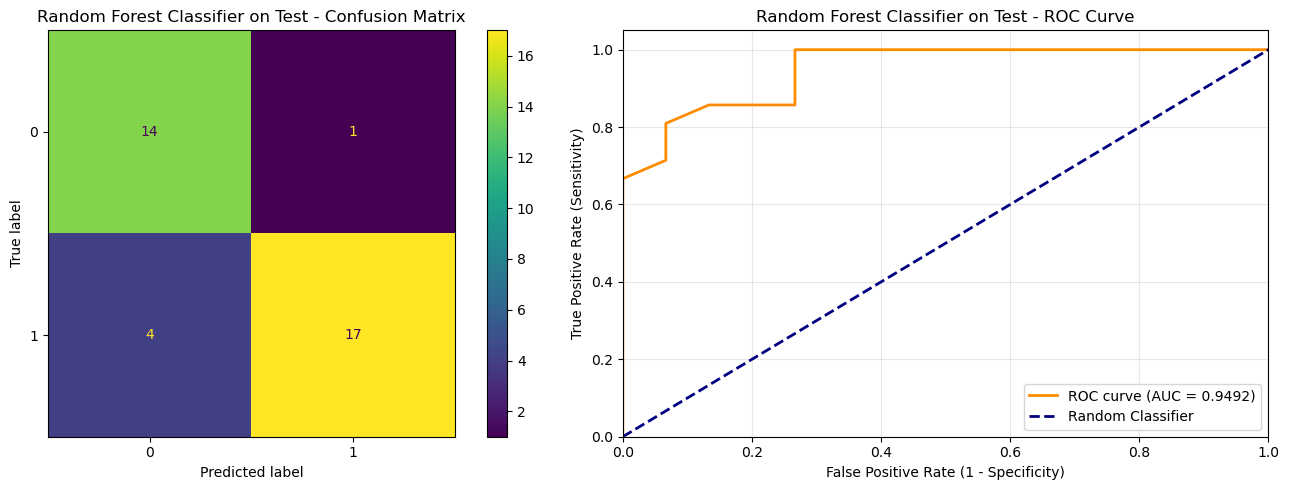

Random Forest Classifier on Test Performance:
Accuracy:     0.8611
Precision:    0.9444
Recall:       0.8095
F1-Score:     0.8718
Sensitivity:  0.8095
Specificity:  0.9333
AUC:          0.9492

Confusion Matrix:
            Predicted
            Neg   Pos
Actual Neg   14     1
       Pos    4    17


In [27]:

results['Random Forest Classifier on Test'] = evaluate_classifier(y_test, test_predict, test_prob, "Random Forest Classifier on Test")


MODEL COMPARISON SUMMARY
                                                             Model  Accuracy  \
SVM kernel on Test                              SVM kernel on Test  0.916667   
SVM on Test                                            SVM on Test  0.888889   
KNN on Test                                      KNN (K=8) on Test  0.888889   
Logistic Regression on Test            Logistic Regression on Test  0.861111   
Random Forest Classifier on Test  Random Forest Classifier on Test  0.861111   
Decision Tree on Test              Decision Tree (depth=2) on Test  0.833333   

                                 Precision    Recall  F1-Score Sensitivity  \
SVM kernel on Test                     1.0  0.857143  0.923077    0.857143   
SVM on Test                       0.947368  0.857143       0.9    0.857143   
KNN on Test                       0.947368  0.857143       0.9    0.857143   
Logistic Regression on Test       0.944444  0.809524  0.871795    0.809524   
Random Forest Classifie

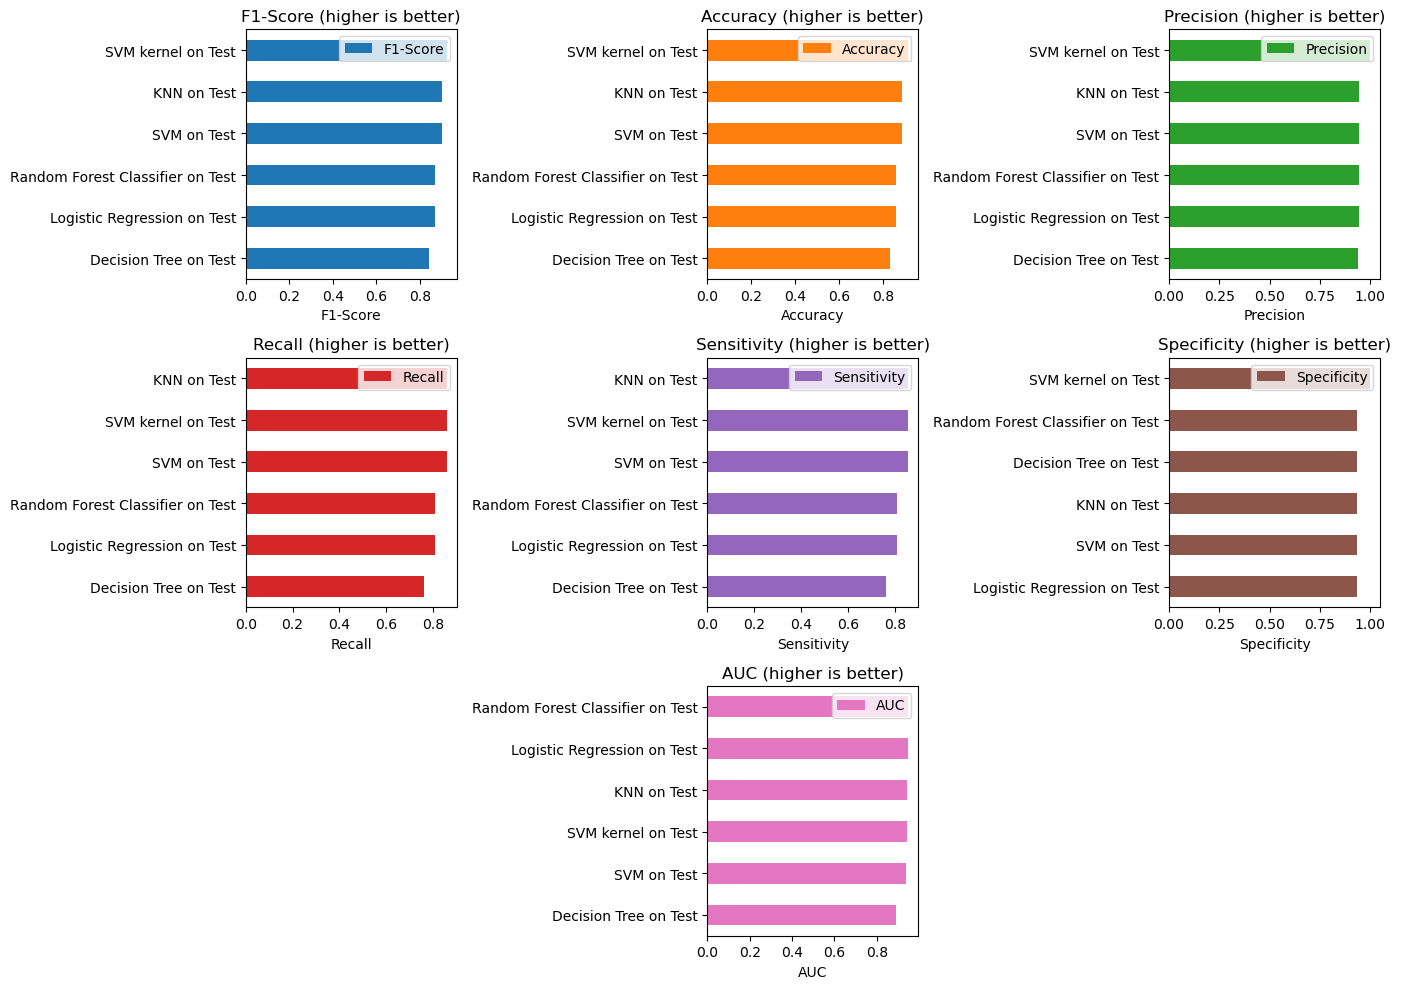

In [31]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.sort_values('F1-Score', ascending=False))

# Visualization with hidden redundant axes and custom colors
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

# Define a consistent color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

# F1-Score comparison
results_df.sort_values('F1-Score', ascending=True).plot(kind='barh', y='F1-Score', ax=axes[0,0], color=colors[0])
axes[0,0].set_title('F1-Score (higher is better)', fontsize=12)
axes[0,0].set_xlabel('F1-Score')
axes[0,0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Accuracy comparison
results_df.sort_values('Accuracy', ascending=True).plot(kind='barh', y='Accuracy', ax=axes[0,1], color=colors[1])
axes[0,1].set_title('Accuracy (higher is better)', fontsize=12)
axes[0,1].set_xlabel('Accuracy')

# Precision comparison
results_df.sort_values('Precision', ascending=True).plot(kind='barh', y='Precision', ax=axes[0,2], color=colors[2])
axes[0,2].set_title('Precision (higher is better)', fontsize=12)
axes[0,2].set_xlabel('Precision')

# Recall comparison
results_df.sort_values('Recall', ascending=True).plot(kind='barh', y='Recall', ax=axes[1,0], color=colors[3])
axes[1,0].set_title('Recall (higher is better)', fontsize=12)
axes[1,0].set_xlabel('Recall')

# Sensitivity comparison
results_df.sort_values('Sensitivity', ascending=True).plot(kind='barh', y='Sensitivity', ax=axes[1,1], color=colors[4])
axes[1,1].set_title('Sensitivity (higher is better)', fontsize=12)
axes[1,1].set_xlabel('Sensitivity')

# Specificity comparison
results_df.sort_values('Specificity', ascending=True).plot(kind='barh', y='Specificity', ax=axes[1,2], color=colors[5])
axes[1,2].set_title('Specificity (higher is better)', fontsize=12)
axes[1,2].set_xlabel('Specificity')

# AUC comparison
results_df.sort_values('AUC', ascending=True).plot(kind='barh', y='AUC', ax=axes[2,1], color=colors[6])
axes[2,1].set_title('AUC (higher is better)', fontsize=12)
axes[2,1].set_xlabel('AUC')

# Hide the two redundant axes (bottom-left and bottom-right)
axes[2,0].set_visible(False)
axes[2,2].set_visible(False)

plt.tight_layout()
plt.show()


# Best Binary Classification Metric: F1-Score

1. **Both False Positives and False Negatives matter**: 
   - False Positive: Misclassifying wine cultivar A as B
   - False Negative: Missing a true cultivar A
   Both errors have similar costs in wine classification.

2. **Harmonic mean advantage**: 
   - F1-Score balances precision and recall providing a single metric that captures both types of errors.

3. **Comparison with alternatives**:
   - Accuracy: Misleading if slight imbalance exists
   - Precision alone: Ignores false negatives
   - Recall alone: Ignores false positives
   - AUC: Good but less intuitive for model comparison


---



# Regularization For Decision Tree:

1. **Limit Maximum Depth (max_depth)**
   - Restricts how deep the tree can grow
   - Smaller depth = simpler model = less overfitting
   - Typical values: 3-10 for most datasets
   - Trade-off: Too shallow may underfit

2. **Minimum Samples Split (min_samples_split)**
   - Minimum number of samples required to split an internal node
   - Higher values prevent splits on small, noisy subsets
   - Typical values: 2-20

3. **Minimum Samples Leaf (min_samples_leaf)**
   - Minimum samples required at a leaf node
   - Prevents creating leaves with very few samples
   - Typical values: 1-5 for small data, 5-20 for larger data
   - Smooths the decision boundary


---

# Linear Vs Kernel SVM:

  ### **Linear SVM**
  
  Use when:

  - Data is linearly separable or nearly linear
  - Large datasets (>10,000 samples)
  - High-dimensional feature space (p >> n)
  - Interpretability is important
  - Quick training needed

  Avoid when:

  - Clear non-linear patterns exist
  - Decision boundary is curved

  ### **Kernel SVM (RBF)**

  Use when:

  - Data has complex non-linear patterns
  - Moderate dataset size (<10,000 samples)
  - You have computational resources
  - Accuracy is more important than interpretability
  - No clear linear boundary exists

  Avoid when:
  
  - Very large datasets (too slow)
  - Interpretability is critical
  - Features are already high-dimensional


# Multiclass Classification Methods

In [83]:
# copy for multi-class classification
multclass_df = copy.deepcopy(df)

In [84]:
# separate the target column 
cultivar = multclass_df.pop('cultivar')

X_train, X_test, y_train, y_test = train_test_split(multclass_df, cultivar, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(142, 13)
(36, 13)


In [85]:
# normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
# evaluate multi-class classification
def evaluate_multiclass(y_test, y_pred, y_prob, model_name):
    
    # Basic metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    # Per-class metrics
    precision_per_class = precision_score(y_test, y_pred, average=None)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    f1_per_class = f1_score(y_test, y_pred, average=None)
    
    # Aggregated metrics
    precision_macro = precision_score(y_test, y_pred, average='macro')
    precision_micro = precision_score(y_test, y_pred, average='micro')
    precision_weighted = precision_score(y_test, y_pred, average='weighted')
    
    recall_macro = recall_score(y_test, y_pred, average='macro')
    recall_micro = recall_score(y_test, y_pred, average='micro')
    recall_weighted = recall_score(y_test, y_pred, average='weighted')
    
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_micro = f1_score(y_test, y_pred, average='micro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    # Log loss
    log_loss_value = log_loss(y_test, y_prob) if y_prob is not None else None
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    
    # Cohen's Kappa
    kappa = cohen_kappa_score(y_test, y_pred)
    
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision (Macro)': precision_macro,
        'Precision (Micro)': precision_micro,
        'Precision (Weighted)': precision_weighted,
        'Recall (Macro)': recall_macro,
        'Recall (Micro)': recall_micro,
        'Recall (Weighted)': recall_weighted,
        'F1 (Macro)': f1_macro,
        'F1 (Micro)': f1_micro,
        'F1 (Weighted)': f1_weighted,
        'Log Loss': log_loss_value,
        'Kappa': kappa
    }
    
    print(f"{model_name} Performance:")
    print(f"Accuracy:           {accuracy:.4f}")
    print(f"Cohen's Kappa:      {kappa:.4f}")
    print(f"Log Loss:           {log_loss_value:.4f}" if log_loss_value else "Log Loss: N/A")
    print(f"\nPer-Class Performance:")
    for i in range(3):
        print(f"  Class {i}: Precision={precision_per_class[i]:.4f}, Recall={recall_per_class[i]:.4f}, F1={f1_per_class[i]:.4f}")
    print(f"\nAggregated Metrics:")
    print(f"  Macro Average:     Precision={precision_macro:.4f}, Recall={recall_macro:.4f}, F1={f1_macro:.4f}")
    print(f"  Micro Average:     Precision={precision_micro:.4f}, Recall={recall_micro:.4f}, F1={f1_micro:.4f}")
    print(f"  Weighted Average:  Precision={precision_weighted:.4f}, Recall={recall_weighted:.4f}, F1={f1_weighted:.4f}")
    
    return results

In [36]:
# svm 
svm_ovr = SVC(kernel='rbf', decision_function_shape='ovr', probability=True, random_state=42)
model = svm_ovr
model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [37]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None

SVM (OVR) on Test Performance:
Accuracy:           1.0000
Cohen's Kappa:      1.0000
Log Loss:           0.0402

Per-Class Performance:
  Class 0: Precision=1.0000, Recall=1.0000, F1=1.0000
  Class 1: Precision=1.0000, Recall=1.0000, F1=1.0000
  Class 2: Precision=1.0000, Recall=1.0000, F1=1.0000

Aggregated Metrics:
  Macro Average:     Precision=1.0000, Recall=1.0000, F1=1.0000
  Micro Average:     Precision=1.0000, Recall=1.0000, F1=1.0000
  Weighted Average:  Precision=1.0000, Recall=1.0000, F1=1.0000


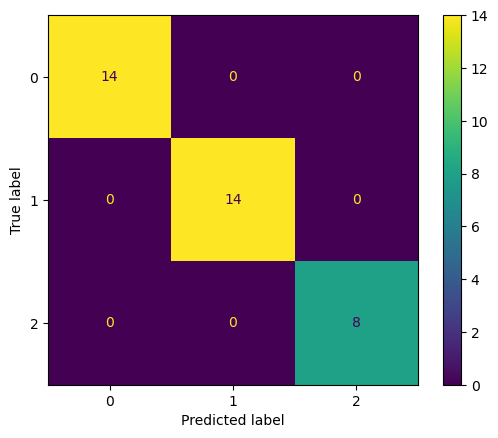

In [38]:
results = {}
results['SVM (OVR) on Test'] = evaluate_multiclass(y_test, test_predict, test_prob, "SVM (OVR) on Test")

In [87]:
# logistic regression (ovr)
lr_ovr = LogisticRegression(multi_class='ovr', solver='liblinear', random_state=42)
model = lr_ovr
model.fit(X_train_scaled, y_train)

c:\Users\melin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr', random_state=42, solver='liblinear')

In [88]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None

Logistic Regression (OVR) on Test Performance:
Accuracy:           1.0000
Cohen's Kappa:      1.0000
Log Loss:           0.0701

Per-Class Performance:
  Class 0: Precision=1.0000, Recall=1.0000, F1=1.0000
  Class 1: Precision=1.0000, Recall=1.0000, F1=1.0000
  Class 2: Precision=1.0000, Recall=1.0000, F1=1.0000

Aggregated Metrics:
  Macro Average:     Precision=1.0000, Recall=1.0000, F1=1.0000
  Micro Average:     Precision=1.0000, Recall=1.0000, F1=1.0000
  Weighted Average:  Precision=1.0000, Recall=1.0000, F1=1.0000


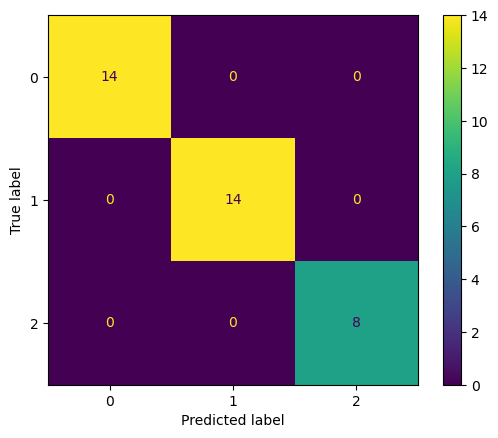

In [89]:

results['Logistic Regression (OVR) on Test'] = evaluate_multiclass(y_test, test_predict, test_prob, "Logistic Regression (OVR) on Test")

In [97]:
# check the weights
weights_logreg = model.coef_

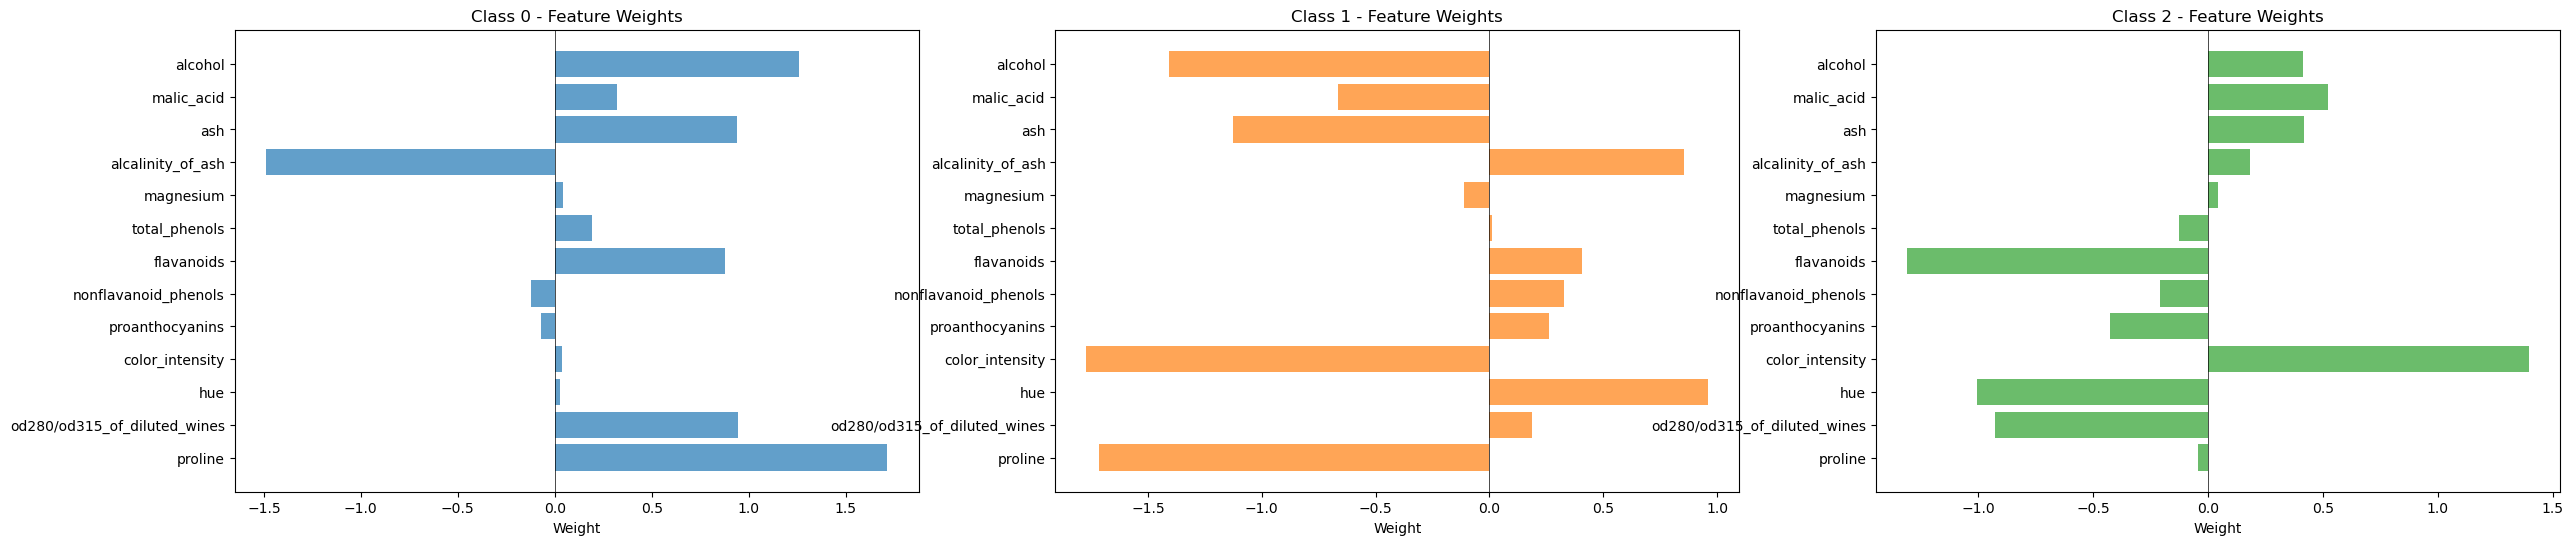

In [104]:
# visualization of the weights
n_features = weights_logreg.shape[1]

feature_names = list(multclass_df.columns)  

fig, axes = plt.subplots(1, 3, figsize=(30, 6))

# Color palette for each class
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
class_names = ['Class 0', 'Class 1', 'Class 2']  

for i in range(3):
    ax = axes[i]
    weights = weights_logreg[i]
    y_pos = np.arange(n_features)
    
    # Horizontal bar chart
    bars = ax.barh(y_pos, weights, color=colors[i], alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feature_names)
    ax.invert_yaxis()  
    ax.set_xlabel('Weight')
    ax.set_title(f'{class_names[i]} - Feature Weights')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)  

In [42]:
# logistic regression (multinomial)
lr_multinomial = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)
model = lr_multinomial
model.fit(X_train_scaled, y_train)

c:\Users\melin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial', random_state=42)

In [43]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None

Logistic Regression (Multinomial) on Test Performance:
Accuracy:           1.0000
Cohen's Kappa:      1.0000
Log Loss:           0.0285

Per-Class Performance:
  Class 0: Precision=1.0000, Recall=1.0000, F1=1.0000
  Class 1: Precision=1.0000, Recall=1.0000, F1=1.0000
  Class 2: Precision=1.0000, Recall=1.0000, F1=1.0000

Aggregated Metrics:
  Macro Average:     Precision=1.0000, Recall=1.0000, F1=1.0000
  Micro Average:     Precision=1.0000, Recall=1.0000, F1=1.0000
  Weighted Average:  Precision=1.0000, Recall=1.0000, F1=1.0000


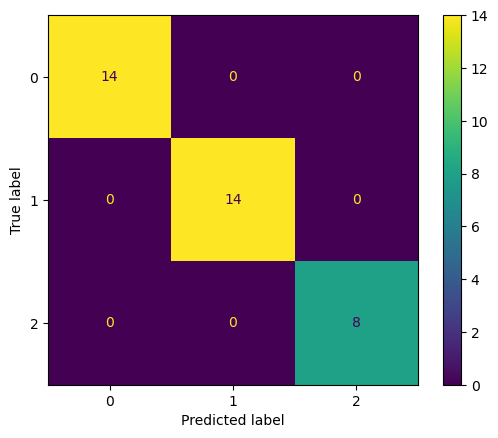

In [44]:

results['Logistic Regression (Multinomial) on Test'] = evaluate_multiclass(y_test, test_predict, test_prob, "Logistic Regression (Multinomial) on Test")

Best K value: 13 (Macro F1-score: 0.9663)


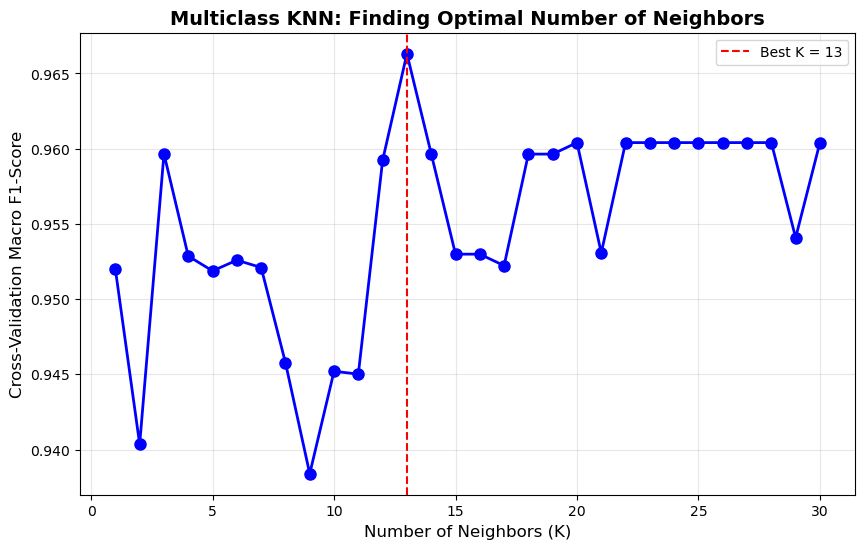

In [45]:
# tune k-values
k_values = range(1, 31)
knn_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='f1_macro')
    knn_scores.append(scores.mean())

best_k = k_values[np.argmax(knn_scores)]
best_score = max(knn_scores)

print(f"Best K value: {best_k} (Macro F1-score: {best_score:.4f})")

# plot K vs Performance
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_values, knn_scores, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
ax.set_xlabel('Number of Neighbors (K)', fontsize=12)
ax.set_ylabel('Cross-Validation Macro F1-Score', fontsize=12)
ax.set_title('Multiclass KNN: Finding Optimal Number of Neighbors', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [46]:
# knn (trained with k = 13)
knn_best = KNeighborsClassifier(n_neighbors=best_k)
model = knn_best
model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=13)

In [47]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None

Multiclass KNN (K=13) on Test Performance:
Accuracy:           0.9722
Cohen's Kappa:      0.9571
Log Loss:           0.0803

Per-Class Performance:
  Class 0: Precision=0.9333, Recall=1.0000, F1=0.9655
  Class 1: Precision=1.0000, Recall=0.9286, F1=0.9630
  Class 2: Precision=1.0000, Recall=1.0000, F1=1.0000

Aggregated Metrics:
  Macro Average:     Precision=0.9778, Recall=0.9762, F1=0.9762
  Micro Average:     Precision=0.9722, Recall=0.9722, F1=0.9722
  Weighted Average:  Precision=0.9741, Recall=0.9722, F1=0.9722


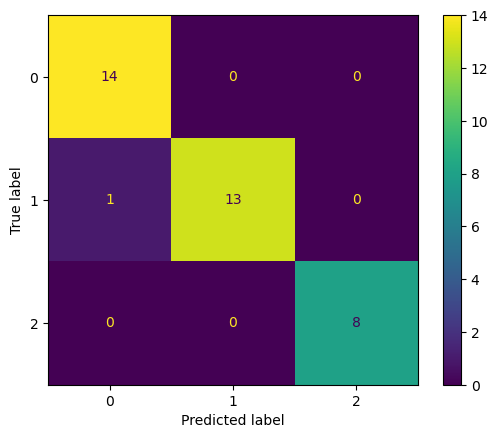

In [48]:

results['Multiclass KNN on Test'] = evaluate_multiclass(y_test, test_predict, test_prob, f"Multiclass KNN (K={best_k}) on Test")

Best max_depth: 3 (Macro F1: 0.9239)


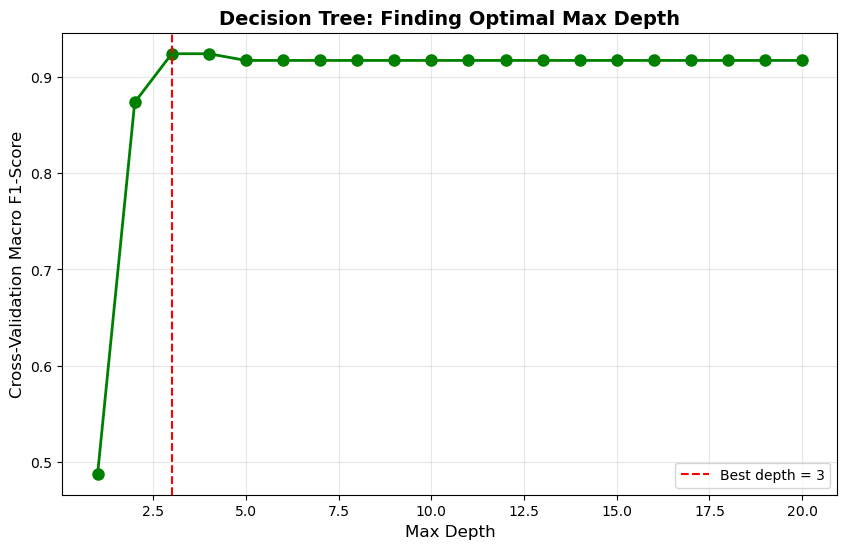

In [105]:
# tune tree depth 
depth_values = range(1, 21)
dt_scores = []

for depth in depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt, X_train_scaled, y_train, cv=5, scoring='f1_macro')
    dt_scores.append(scores.mean())

best_depth = depth_values[np.argmax(dt_scores)]
print(f"Best max_depth: {best_depth} (Macro F1: {max(dt_scores):.4f})")

# plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depth_values, dt_scores, 'go-', linewidth=2, markersize=8)
ax.axvline(x=best_depth, color='red', linestyle='--', label=f'Best depth = {best_depth}')
ax.set_xlabel('Max Depth', fontsize=12)
ax.set_ylabel('Cross-Validation Macro F1-Score', fontsize=12)
ax.set_title('Decision Tree: Finding Optimal Max Depth', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [106]:
# decision tree (trained with depth = 3)
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
model = dt_best
model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [107]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None

Decision Tree (depth=3) on Test Performance:
Accuracy:           0.9444
Cohen's Kappa:      0.9137
Log Loss:           2.0122

Per-Class Performance:
  Class 0: Precision=1.0000, Recall=0.9286, F1=0.9630
  Class 1: Precision=0.8750, Recall=1.0000, F1=0.9333
  Class 2: Precision=1.0000, Recall=0.8750, F1=0.9333

Aggregated Metrics:
  Macro Average:     Precision=0.9583, Recall=0.9345, F1=0.9432
  Micro Average:     Precision=0.9444, Recall=0.9444, F1=0.9444
  Weighted Average:  Precision=0.9514, Recall=0.9444, F1=0.9449


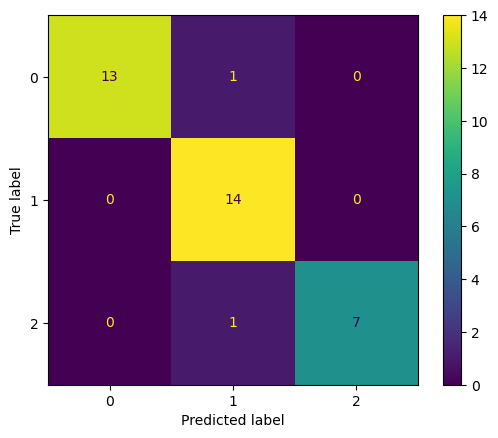

In [108]:

results['Decision Tree on Test'] = evaluate_multiclass(y_test, test_predict, test_prob, f"Decision Tree (depth={best_depth}) on Test")

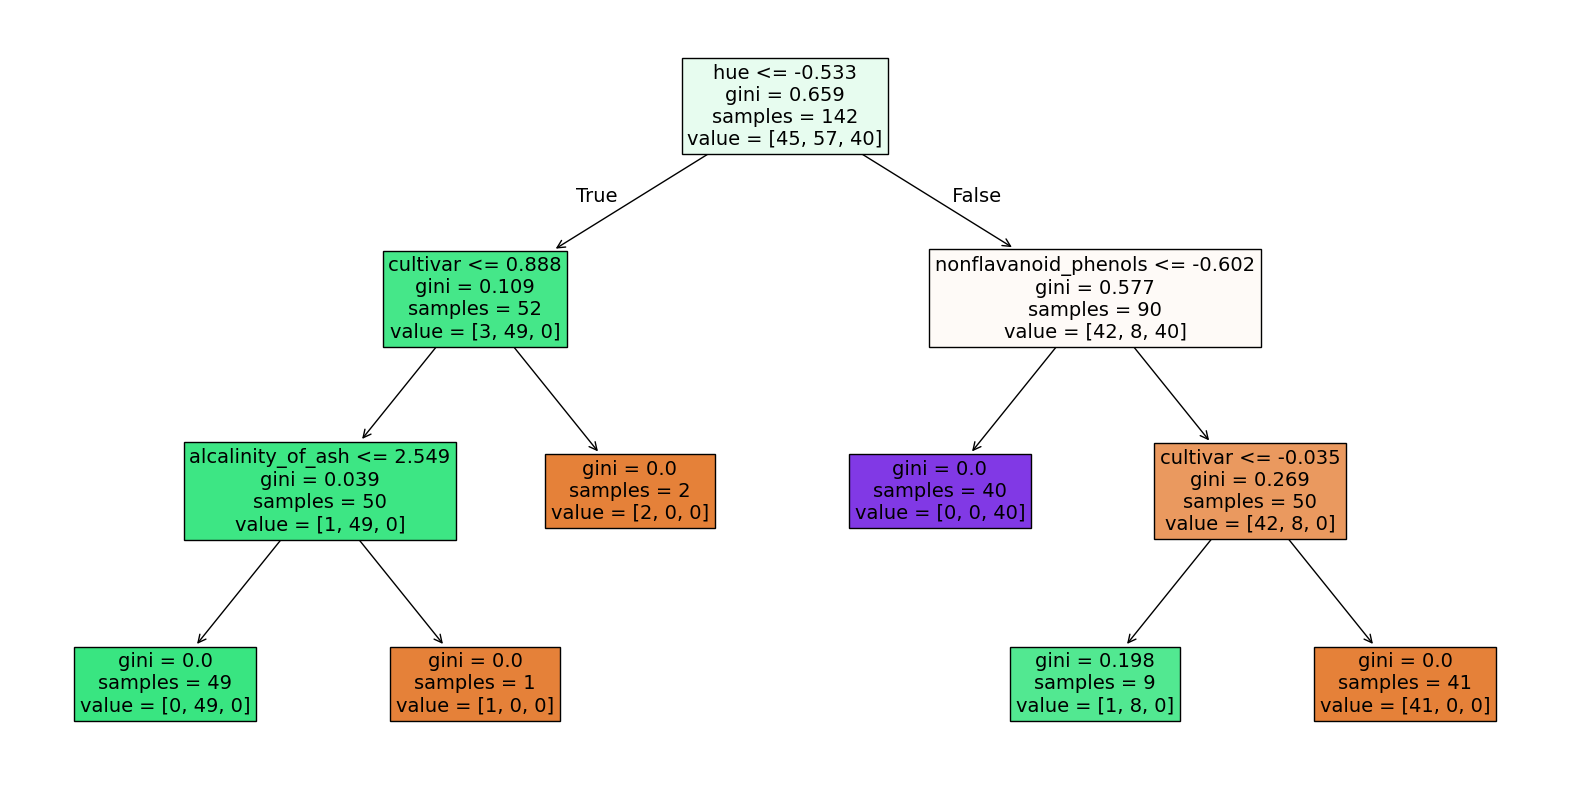

In [109]:
# tree visualisation
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (20,10))
tree.plot_tree(model,feature_names = biclass_df.columns, filled = True, fontsize=14);

In [ ]:
# xgboost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
model = xgb
model.fit(X_train_scaled, y_train)

In [ ]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None

In [ ]:

results['XGBOOST on Test'] = evaluate_multiclass(y_test, test_predict, test_prob, "XGBOOST on Test")

In [ ]:
# lightgbm
lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbose=-1)
model = lgbm
model.fit(X_train_scaled, y_train)

In [ ]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None

In [ ]:

results['LightGBM on Test'] = evaluate_multiclass(y_test, test_predict, test_prob, "LightGBM on Test")

In [ ]:

fig,ax = plt.subplots(figsize=(20,10))

# plot importances with feature weight
plot_importance(
    booster=model,
    ax=ax
)

plt.show()

In [54]:
# adaboost
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model = ada
model.fit(X_train_scaled, y_train)

AdaBoostClassifier(learning_rate=0.1, n_estimators=100, random_state=42)

In [55]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None

ADABOOST on Test Performance:
Accuracy:           0.9167
Cohen's Kappa:      0.8714
Log Loss:           0.9093

Per-Class Performance:
  Class 0: Precision=0.9333, Recall=1.0000, F1=0.9655
  Class 1: Precision=0.9231, Recall=0.8571, F1=0.8889
  Class 2: Precision=0.8750, Recall=0.8750, F1=0.8750

Aggregated Metrics:
  Macro Average:     Precision=0.9105, Recall=0.9107, F1=0.9098
  Micro Average:     Precision=0.9167, Recall=0.9167, F1=0.9167
  Weighted Average:  Precision=0.9164, Recall=0.9167, F1=0.9156


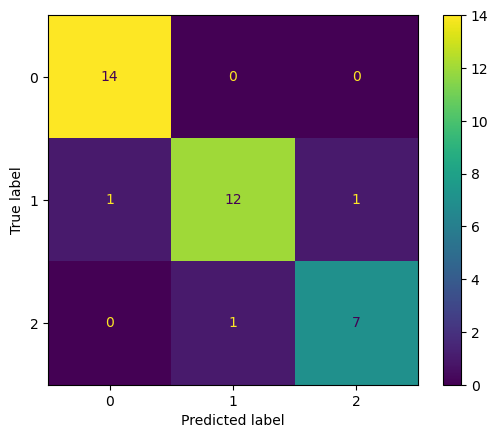

In [56]:

results['AdaBOOST on Test'] = evaluate_multiclass(y_test, test_predict, test_prob, "ADABOOST on Test")

In [ ]:
# catboost
catboost = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=5, random_seed=42, verbose=False)
model = catboost
model.fit(X_train_scaled, y_train)

In [ ]:

test_predict = model.predict(X_test_scaled)
test_prob = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None

In [ ]:

results['CatBOOST on Test'] = evaluate_multiclass(y_test, test_predict, test_prob, "CatBOOST on Test")


MODEL COMPARISON SUMMARY
                                                                               Model  \
SVM (OVR) on Test                                                  SVM (OVR) on Test   
Logistic Regression (OVR) on Test                  Logistic Regression (OVR) on Test   
Logistic Regression (Multinomial) on Test  Logistic Regression (Multinomial) on Test   
Multiclass KNN on Test                                 Multiclass KNN (K=13) on Test   
Decision Tree on Test                                Decision Tree (depth=3) on Test   
AdaBOOST on Test                                                    ADABOOST on Test   

                                           Accuracy Precision (Macro)  \
SVM (OVR) on Test                               1.0               1.0   
Logistic Regression (OVR) on Test               1.0               1.0   
Logistic Regression (Multinomial) on Test       1.0               1.0   
Multiclass KNN on Test                     0.972222          0.97

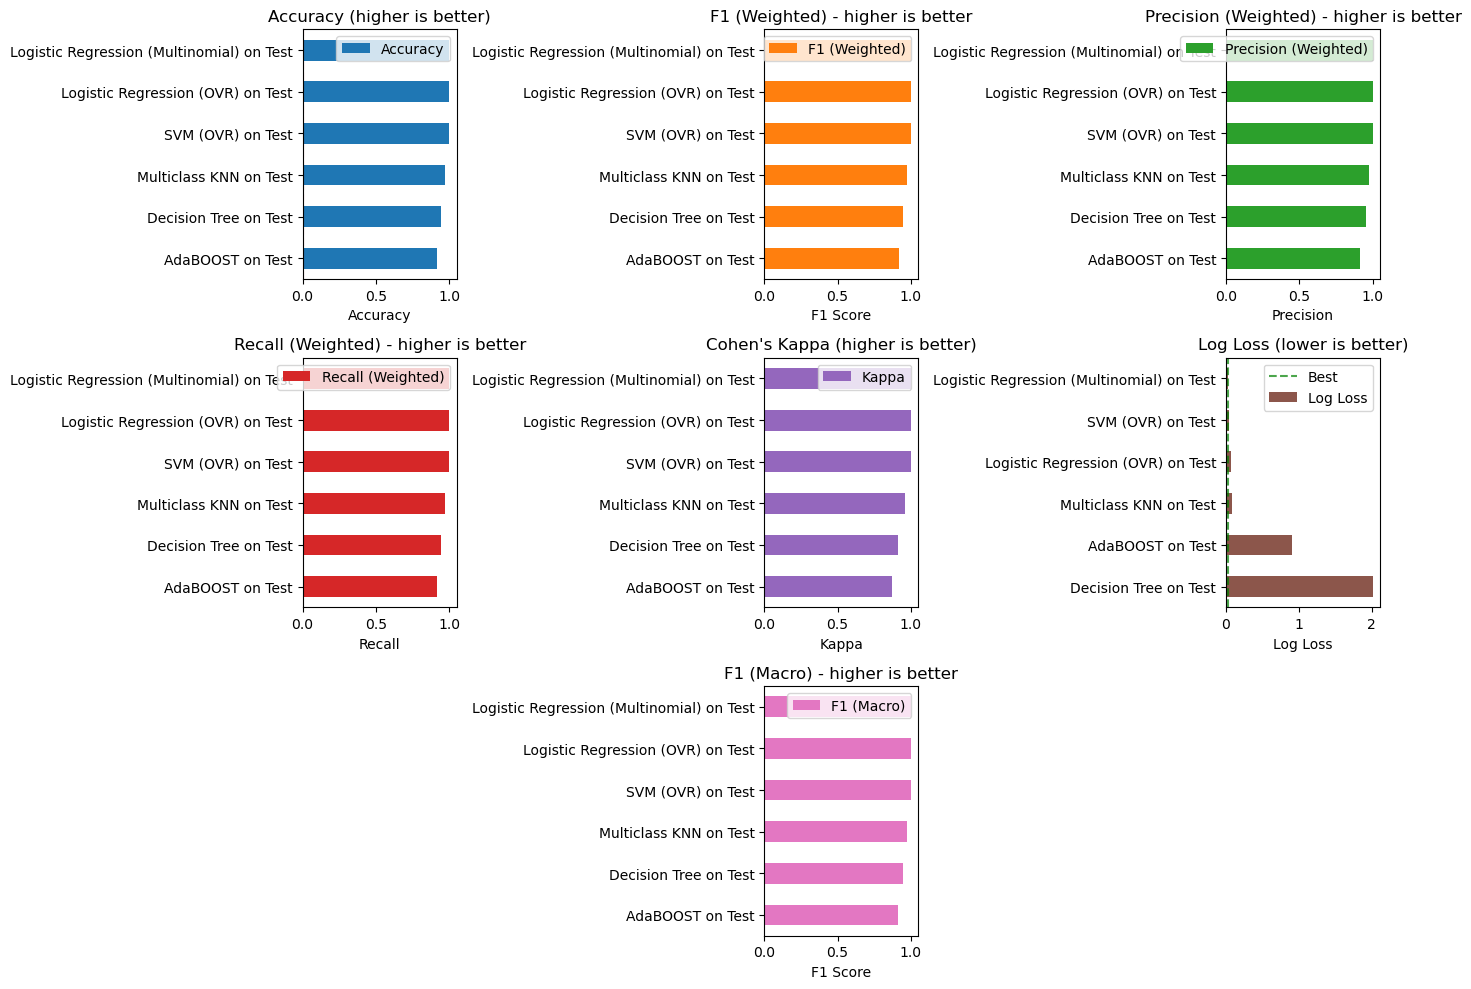

In [58]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.sort_values('F1 (Weighted)', ascending=False))

# Visualization - 3x3 grid, hiding 2 redundant axes
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

# Define color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

# 1. Accuracy
results_df.sort_values('Accuracy', ascending=True).plot(kind='barh', y='Accuracy', ax=axes[0,0], color=colors[0])
axes[0,0].set_title('Accuracy (higher is better)', fontsize=12)
axes[0,0].set_xlabel('Accuracy')
axes[0,0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# 2. F1 (Weighted) - primary metric
results_df.sort_values('F1 (Weighted)', ascending=True).plot(kind='barh', y='F1 (Weighted)', ax=axes[0,1], color=colors[1])
axes[0,1].set_title('F1 (Weighted) - higher is better', fontsize=12)
axes[0,1].set_xlabel('F1 Score')

# 3. Precision (Weighted)
results_df.sort_values('Precision (Weighted)', ascending=True).plot(kind='barh', y='Precision (Weighted)', ax=axes[0,2], color=colors[2])
axes[0,2].set_title('Precision (Weighted) - higher is better', fontsize=12)
axes[0,2].set_xlabel('Precision')

# 4. Recall (Weighted)
results_df.sort_values('Recall (Weighted)', ascending=True).plot(kind='barh', y='Recall (Weighted)', ax=axes[1,0], color=colors[3])
axes[1,0].set_title('Recall (Weighted) - higher is better', fontsize=12)
axes[1,0].set_xlabel('Recall')

# 5. Kappa
results_df.sort_values('Kappa', ascending=True).plot(kind='barh', y='Kappa', ax=axes[1,1], color=colors[4])
axes[1,1].set_title("Cohen's Kappa (higher is better)", fontsize=12)
axes[1,1].set_xlabel('Kappa')

# 6. Log Loss (lower is better)
results_df.sort_values('Log Loss', ascending=False).plot(kind='barh', y='Log Loss', ax=axes[1,2], color=colors[5])
axes[1,2].set_title('Log Loss (lower is better)', fontsize=12)
axes[1,2].set_xlabel('Log Loss')
axes[1,2].axvline(x=results_df['Log Loss'].min(), color='green', linestyle='--', alpha=0.7, label='Best')
axes[1,2].legend()

# 7. F1 (Macro) - additional
results_df.sort_values('F1 (Macro)', ascending=True).plot(kind='barh', y='F1 (Macro)', ax=axes[2,1], color=colors[6])
axes[2,1].set_title('F1 (Macro) - higher is better', fontsize=12)
axes[2,1].set_xlabel('F1 Score')

# Hide redundant axes (bottom-left and bottom-right)
axes[2,0].set_visible(False)
axes[2,2].set_visible(False)

plt.tight_layout()
plt.show()


# Best Multi-Class Classification Metric: Weighted F1-Score

1. **Class Distribution Consideration**:
   - The wine dataset has 59, 71, and 48 samples across 3 classes
   - This is reasonably balanced but not perfectly equal
   - Weighted F1 accounts for class imbalance while maintaining interpretability

2. **Why Not Other Metrics**:
   - **Accuracy**: Can be misleading if classes were imbalanced
   - **Macro F1**: Treats all classes equally, ignoring natural frequency
   - **Micro F1**: Dominated by majority class performance
   - **Weighted F1**: Best of both worlds - weights by class support

---
   

# Multi-Label Classification 

### 1. **KNN**:

   Approach 1: Binary Relevance (BR-KNN)
   
   - Train one KNN classifier per label (independent)
   - For L labels, create L separate KNN models
   - Each model predicts presence/absence of that label
   - Prediction: K nearest neighbors vote for each label independently
   
   Approach 2: ML-KNN (Multi-Label K-Nearest Neighbors)

   - Find K nearest neighbors for each instance
   - Count how many neighbors have each label
   - Use maximum a posteriori (MAP) principle for prediction
   - Formula: P(label_j=1) = (prior + neighbor_count) / (K + total_instances)
   
   Approach 3: Adapted KNN with Label Sets
 
   - Treat each unique combination of labels as a "class"
   - Standard KNN predicts the most common label set among neighbors
   - Only works if number of label combinations is manageable

### 2. **Decision Trees**:

   Approach 1: Multi-Label Decision Tree (ML-DT)

   - Modified splitting criteria using multi-label entropy
   - Formula: Multi-Label Entropy = -Σ p(Y) log p(Y)
   - Each leaf contains a label subset (not a single class)
   - Uses multi-label information gain for splits
   
   Approach 2: Label Powerset Transformation

   - Transform multi-label problem into multi-class
   - Each unique label combination becomes a new class
   - Build standard decision tree on transformed classes
   - Limitation: Number of classes = 2^L (can be huge)
   
   Approach 3: Ensemble of Classifier Chains

   - Build chain of decision trees where each predicts one label
   - Previous label predictions become features for next
   - Captures label dependencies

---


# Metric For Football Multi-Label Classification:

1. **Hamming Loss**

   Formula: Hamming Loss = (1/N) × Σ(1/L) × Σ(1_{y_ij ≠ ŷ_ij})
   
   Why it's best:

   - Treats each label independently (appropriate for unrelated labels)

   - Penalizes individual label mistakes equally

   - Easy to interpret: "fraction of incorrect label predictions"
    
   - Range [0,1], lower is better
   
   Example: For 4 labels and 100 players
   - If model makes 50 total label errors, Hamming Loss = 50/(100×4) = 0.125
   - Meaning: 12.5% of label predictions were wrong

2. **Subset Accuracy (Exact Match Ratio)**

   - Percentage of players where ALL 4 labels are predicted correctly
   - Very strict - only perfect predictions count
   - Important for applications requiring complete accuracy

3. **Label Ranking Average Precision**

   - Useful if you can rank labels by confidence
   - Measures whether positive labels are ranked higher than negatives

# Challenging Questions


# 1. Bias–Variance Trade‑off in Regression Models

The bias–variance trade‑off describes how prediction error decomposes into:

- **Bias**: Error from overly simple assumptions (underfitting). High‑bias models miss true relationships.
- **Variance**: Error from sensitivity to small fluctuations in training data (overfitting). High‑variance models fit noise.
- **Irreducible error**: Noise inherent in the data.

**Total Error = Bias² + Variance + Irreducible Error**

As model complexity increases:
- Bias decreases (model captures more patterns)
- Variance increases (model becomes more sensitive)
- There is an optimal complexity minimising total error.

*Example (Wine regression predicting alcohol)*:  
Linear regression – moderate bias, moderate variance.  
Deep decision tree – low bias, high variance (overfits).  
Ridge (high α) – increased bias, reduced variance.

---

# 2. Kernel Regression Vs Linear Regression

Kernel regression (e.g., KernelRidge with RBF) outperforms linear regression when the true relationship is **non‑linear but smooth**.

**Examples**:
- Wine dataset: alcohol may have non‑linear interactions (flavanoids × colour intensity).
- Sinusoidal or quadratic functions.

**Why** – Kernels implicitly map features to higher dimensions where linear separation works, without explicit computation.

**Caveat**: Slower (O(n³)), curse of dimensionality. Linear regression preferred for large, high‑dim, or linear data.

---

# 3. L1 vs L2 Regularization

| Property | L1 (LASSO) | L2 (Ridge) |
|----------|------------|------------|
| Penalty term | α Σ|βᵢ| | α Σ βᵢ² |
| Effect on coefficients | Shrinks some **exactly to zero** | Shrinks toward zero but not zero |
| Feature selection | Yes (sparse) | No |
| Correlated features | Picks one arbitrarily | Shrinks together, stable |
| Solution uniqueness | Not always unique | Always unique |

**When does LASSO perform better?**  
- High‑dim data with many irrelevant features (feature selection desired).  
- Need a sparse, interpretable model.

**When does Ridge perform better?**  
- Many features are relevant, even if weakly.  
- Features are highly correlated.  
- Prediction accuracy (not interpretability) is the main goal.

**Why does LASSO produce sparsity?**  
The L1 penalty has a diamond‑shaped constraint region. The elliptical error contours tend to touch a corner, forcing some coefficients to zero.

---

# 4. Why is MAPE Unreliable in Some Datasets?

MAPE = (1/n) Σ |(actual – predicted)/actual| × 100%

**Problems**:
1. **Zero/near‑zero actual values** – division by tiny numbers → infinite/huge MAPE.
2. **Asymmetry** – over‑ and under‑predictions are weighted differently.
3. **Scale‑dependent interpretation** – 10% MAPE on [0,1] is not same as on [0,1000].
4. **Negative values** – not defined.

*Example*: Wine alcohol (always >0) – MAPE fine. Price dataset with zero or negative values – useless.

---

# 5. Effect of Outliers on Regression Models

| Model | Sensitivity |
|-------|-------------|
| Linear / Ridge / LASSO | **High** (squared error) |
| Kernel Ridge | Moderate |
| Decision Tree / Random Forest | **Low** (outliers isolated) |
| SVR (ε‑insensitive) | Low |
| Bayesian Ridge | Moderate |

---

# 6. Effect of Class Imbalance on Binary Metrics

**Why accuracy is misleading**  
Example: 95% class‑0, 5% class‑1 – always predicting class‑0 gives 95% accuracy, but model is useless.

**Better metrics**:
- Balanced accuracy = (sensitivity + specificity)/2
- Precision‑Recall AUC (PR‑AUC)
- F1‑score (macro / weighted)

---

# 7. Decision Boundaries of Different Models

| Model | Decision Boundary |
|-------|-------------------|
| Logistic Regression / Linear SVM | Linear hyperplane |
| Kernel SVM (RBF) | Non‑linear, smooth, closed curves |
| KNN | Voronoi tessellation (piecewise constant) |
| Decision Tree | Axis‑aligned rectangles |
| Random Forest | Aggregation of many axis‑aligned rectangles |

**Fundamental difference** – linear models assume linear separators; kernel SVM/KNN can model non‑linear; trees produce axis‑parallel splits (interpretable but not rotation‑invariant).
> Take a look at the bottom, where we trained some models on a toy dataset and visualized the decision boundries.

---

# 8. Effect of K in KNN

- **Small K** – low bias, high variance, jagged boundary, sensitive to outliers.
- **Large K** – higher bias, lower variance, smoother boundary.
- **Optimal K** chosen via cross‑validation.

*On Wine data* – optimal K ≈ 5–15.

---

# 9. Overfitting in Decision Trees

**Why do decision trees overfit easily?**  
They can grow until every leaf is pure – perfect training accuracy but poor generalisation.

**Why is max depth not enough?**  
Even with limited depth, splits on very few samples near leaves can still overfit.

**How pruning works**  
- **Pre‑pruning (early stopping)** – stop splitting when node size < `min_samples_split` or impurity reduction < threshold.
- **Post‑pruning (cost‑complexity pruning)** – grow full tree, then remove subtrees that increase error by less than `ccp_alpha`.

---

# 10. Why Tree‑Based Models are Good Feature Selectors

- Trees rank features by **importance** (Gini impurity reduction, information gain).
- Unused features get importance = 0.
- Random Forest aggregates importance, robust ranking.
- Capture interactions – a feature may be important only when another feature passes a threshold.

---

# 11. Micro vs Macro vs Weighted F1

| Metric | Calculation | Favours |
|--------|-------------|---------|
| **Macro F1** | Average per‑class F1 (unweighted) | All classes equally |
| **Micro F1** | Aggregate TP, FP, FN globally | Large classes |
| **Weighted F1** | Average per‑class F1 weighted by support | Realistic for imbalanced data |

**When is Macro F1 a better reflection?**  
When all classes are equally important (e.g., rare disease detection).

**When is Weighted F1 misleading?**  
When majority class is trivial – weighted F1 can be high despite poor minority performance.

**Why does Micro F1 favour large classes?**  
Micro averages global counts; large classes dominate TP/FP/FN.

---

# 12. Multi‑label vs Multiclass 

| Aspect | Multiclass | Multi‑label |
|--------|-----------|-------------|
| Output | Single integer (0..K-1) | Binary vector of length L |
| Loss | Cross‑entropy, hinge | Binary cross‑entropy per label, Hamming loss |
| Thresholding | Not needed (argmax) | Required (e.g., 0.5) |
| Metrics | Accuracy, macro/micro F1 | Hamming loss, subset accuracy, label‑ranking |

**Why KNN and Decision Trees can be extended to multi‑label?**  
- **KNN** – majority voting per label (binary relevance) or special multi‑label voting (ML‑KNN).  
- **Decision trees** – multi‑label entropy split criteria, or multi‑output wrapper (train one tree per label).

---

# 13. Precision–Recall Trade‑off

**Precision** = TP/(TP+FP) – exactness.  
**Recall** = TP/(TP+FN) – completeness.

Raising classification threshold → higher precision, lower recall.  
Lowering threshold → lower precision, higher recall.

**Trade‑off** – cannot simultaneously perfect both. Optimal balance depends on cost of false positives vs false negatives.

---

# 14. ROC vs PR Curve

| Curve | Axes | Best for | Sensitivity to imbalance |
|-------|------|----------|--------------------------|
| **ROC** | TPR vs FPR | Balanced datasets; when FPs are costly but classes balanced | Less sensitive (FPR from large negative class) |
| **PR** | Precision vs Recall | **Imbalanced datasets** (minority positive class) | Very sensitive |

**Rule** – If positive class is rare (<5%), use PR‑AUC. Otherwise ROC‑AUC fine.

---

# 15. How to Improve Models with Unlimited Time & Resources

## Better Preprocessing
- Robust scaling, quantile transformation.
- Outlier handling (Winsorisation, robust regression).
- Missing value imputation (KNN, iterative).
- Feature engineering (polynomials, interactions, domain transforms).
- Dimensionality reduction (PCA, autoencoders) – careful not to lose interpretability.

## Better Features
- Feature selection (RFE, mutual information, tree importance).
- Generate new features (binning, clustering, target encoding).
- Add external data (more chemical measurements, vintage, region).

## Better Models
- Stacking / blending – meta‑learner on diverse base models.
- Neural networks (MLP, 1D‑CNN) if more data available.
- Hyperparameter optimisation (Bayesian – Optuna, Hyperopt).
- Ensemble diversity (different subsamples, feature subsets).
- Regularisation tuning (exhaustive for L1/L2/Elastic Net).

## Better Metrics
- Probabilistic metrics (Brier score, log‑loss, calibration curves).
- Custom loss functions (asymmetric costs).
- Bootstrap confidence intervals.
- Repeated nested cross‑validation.



>In this part we created a toy dataset to visualize the decision boundries of different models

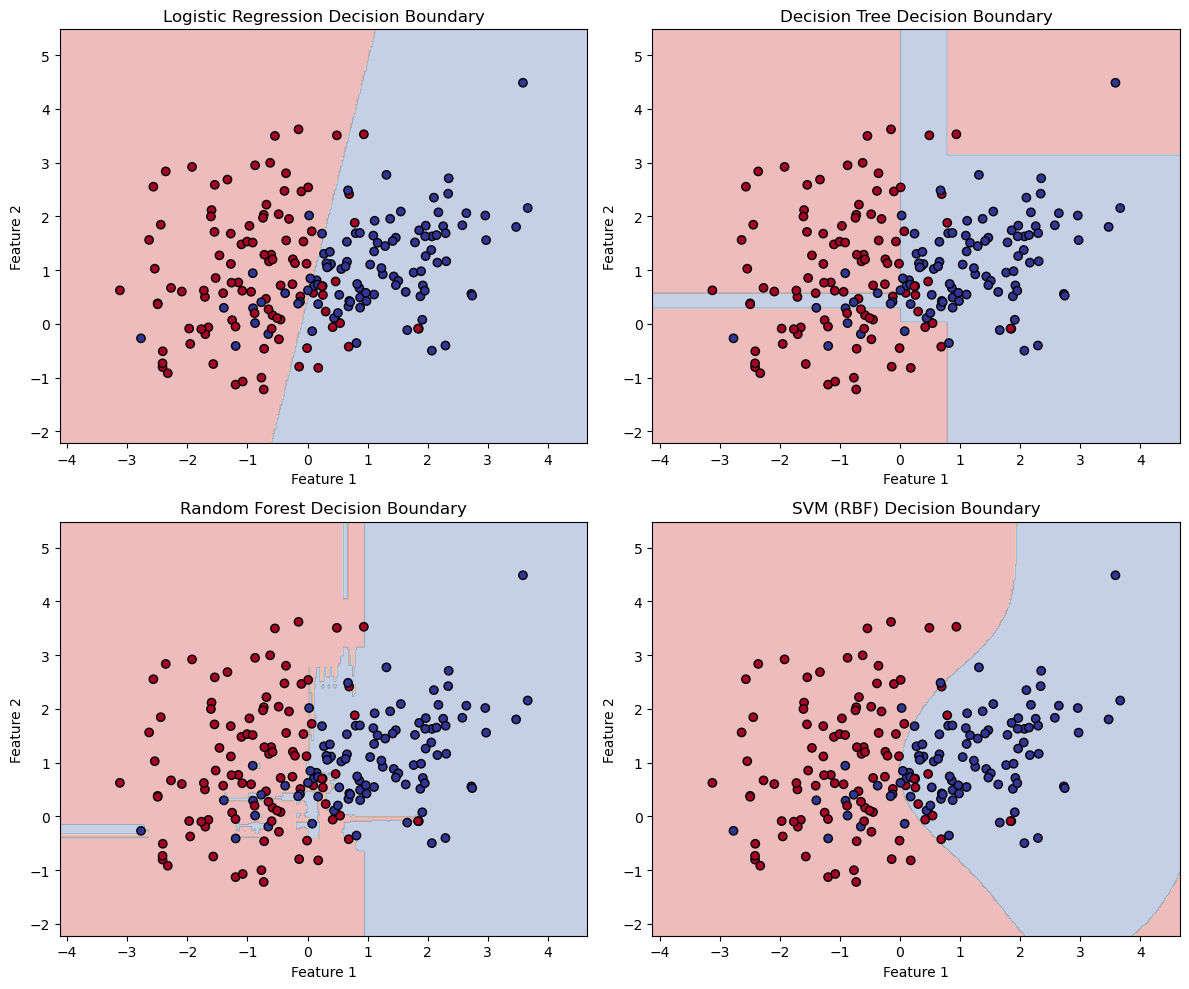


=== DECISION BOUNDARY INTERPRETATION ===
• Logistic Regression: Linear boundary (smooth)
• Decision Tree: Rectangular/axis-aligned boundaries
• Random Forest: More complex, ensemble of trees
• SVM (RBF): Non-linear, curved boundaries


In [4]:

# create 2D toy dataset
X_toy, y_toy = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                                     n_clusters_per_class=1, random_state=42)

# train different classifiers
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(max_depth=3),
    'Random Forest': RandomForestClassifier(n_estimators=50),
    'SVM (RBF)': SVC(kernel='rbf')
}

# create mesh grid
x_min, x_max = X_toy[:, 0].min() - 1, X_toy[:, 0].max() + 1
y_min, y_max = X_toy[:, 1].min() - 1, X_toy[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# plot decision boundaries
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_toy, y_toy)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    axes[idx].scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, cmap='RdYlBu', edgecolors='black')
    axes[idx].set_title(f'{name} Decision Boundary')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# interpretation
print("\n=== DECISION BOUNDARY INTERPRETATION ===")
print("• Logistic Regression: Linear boundary (smooth)")
print("• Decision Tree: Rectangular/axis-aligned boundaries")
print("• Random Forest: More complex, ensemble of trees")
print("• SVM (RBF): Non-linear, curved boundaries")